In [3]:
#collecting legolas data
##### import statistics
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from scipy.stats import sem
from skimage.measure import block_reduce
from scipy import stats,optimize
import statistics
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import pyblock.blocking as blocking
import pyblock.pd_utils as pd_utils

import re 
import emcee
def f(x, k, w, x0, y0):
    return k * np.arctan(w*(x-x0)) + y0
def polynomial(x,A,B):
    return A*(x-x.max())**2+B 
def acf(series):
    n = len(series)
    data = np.asarray(series)
    mean = np.mean(data)
    c0 = np.sum((data - mean) ** 2) / float(n)
    def r(h):
        acf_lag = ((data[:n - h] - mean) * (data[h:] - mean)).sum() / float(n) / c0
        return round(acf_lag, 3)
    x = np.arange(n) # Avoiding lag 0 calculation
    acf_coeffs = list(map(r, x))
    return acf_coeffs


def tau_cal(acf_out,nums):
    positive_acf =np.where(acf_out > 0.0000)[0]
                
    result = [acf_out[x] for x in positive_acf]
    tau = 1 + 2 * np.sum(result[1:-1])
    Neff = len(nums)/tau
    error = (statistics.stdev(nums))/np.sqrt(Neff)
    return error
    
    


    
def do_block_averaging(corr):
                    sems = list()
                    x=np.arange(len(corr))
                    #for blocksize in range(1, int(len(corr)//25)+1):
                    for blocksize in range(1, int(len(corr)**(2/3))+1):
                        #this is the blocking bit:
                        x_ = x[:len(x)-(len(x)%blocksize)].reshape(-1,blocksize).mean(1)
                        y_ = corr[:len(x)-(len(x)%blocksize)].reshape(-1,blocksize).mean(1)
                        sems.append(sem(y_))
                    return sems
class shift_reader:
    def __init__(self,filename,id1,id2,l):
        self.filename=filename
        self.id1=id1
        self.id2=id2
        self.temp=l
    def stdev_plot(self):

            df = pd.read_csv(self.filename)
            #print(df["CHEMICAL_SHIFT"][195])
            #shift = df["CHEMICAL_SHIFT"]
            shift = df['CHEMICAL_SHIFT'].str.split(',')
            
            #result = [x.strip() for x in shift.split(',')]
            #shift2 = shift[5].split('[')
            #print(shift[5])
            Type = []
            
            
            for e in range(self.id1,self.id2):
                nums = []
                time= []
                p = shift[e]
                l = 0
                i = 0
                for h in p:

                    x  = re.split(r'\[|\]',h)


                    if (len(x)>1) and (i == 0):
                        
                        #print(temp,resid, x)
                        
                        nums.append(float(x[1]))
                        i = i+1
                        time.append(i*4e-15*7000*1e9)

                    else:
                        #print(x)
                        
                        nums.append(float(x[0]))
                        i = i+1
                        time.append(i*4e-15*7000*1e9)
                #print(nums)
                nums = np.array(nums)
                
                #plt.plot(time,nums)
                #plt.show()
                #print(nums)
                #auto = int(np.round(emcee.autocorr.integrated_time((nums-statistics.mean(nums))/statistics.stdev(nums)))[0])
                #print('auto',auto)
                mean_store = []
                block_size=[]
                no_blocks=[]
                block_size_no=[]
                sem=[]
                
                #return sems
                for n_blocks in range(400,10,-1):
                    #block_size.append(i)
                    #block_mean=[]
                    #no_blocks=0
                    #mean=0
                    #for l in range(0, len(nums),i):
                    #    print(l)
                    #    if len(nums[:l+i])==i:
                    #        block_mean.append(np.mean(nums[l:l+i]))
                 #           #mean=mean+(np.mean(nums[l:l+i])**2)
                    #        no_blocks=no_blocks+1
                    #sem.append(np.std(block_mean)/np.sqrt(no_blocks))
                    block_size=len(nums)//n_blocks
                    #print(n_blocks,block_size)
                    lim=(int(n_blocks*block_size))
                    blocks=nums[:lim].reshape(n_blocks,block_size)
                    #print(len(blocks[0]))
                    block_mean=blocks.mean(axis=1)
                    #print(*blocks[0])
                    #print(block_mean)
                    no_blocks.append(n_blocks)
                    block_size_no.append(block_size)
                    sem.append(np.std(block_mean)/np.sqrt(n_blocks))
                #plt.plot(block_size_no,sem)
                    #print(sem)
                    
                    
                    
                #sem = do_block_averaging(nums)
                #print(sem)
                sem=np.array(sem)
                block_size_no=np.array(block_size_no)
                #popt,pcov=optimize.curve_fit(f,xdata=block_size_no,ydata = sem,maxfev=1000000,p0=[0.001,0.001,(0.5*(np.max(block_size_no)+np.min(block_size_no))),(0.5*(np.max(sem)+np.min(sem)))],bounds=((0,0,0,0),(np.inf,np.inf,np.inf,np.inf)))
                popt2,pcov2=optimize.curve_fit(polynomial,xdata=block_size_no,ydata = sem,p0=[0.00,0.0002])
                #print(popt)
                #print(popt2)
                plt.ylabel('SEM (ppm)')
                plt.xlabel('block size')
                #plt.plot(block_size_no,f(block_size_no,*popt2))
                #print('f',f(block_size,*popt))
                plt.plot(block_size_no,polynomial(block_size_no,*popt2),label='SEM at '+str(self.temp)+' '+'K')
                #plt.plot(block_size,f(block_size,*popt))
                #print(block_size_no)
                plt.plot(block_size_no,sem,label='Quadratic-plateau at '+str(self.temp)+' '+'K')
                 
                plt.legend()


                #plt.savefig('/blue/colina/dkodituwakku/plots-thesis/sem_5HA.jpg',dpi=300)
                
                #plt.show()
                #plt.ylabel('SEM')
                #plt.xlabel('number of blocks')
                #plt.plot(block_size,f(block_size,*popt))
                
                #plt.plot(no_blocks,sem)
                
                #plt.show()
                #print(nums)
                #while last <= 20000:
                #for l in range(0,len(nums),auto):
                #    mean_store.append(np.mean(nums[l:l+auto]))
                #print(mean_store)
                #means1 = np.mean(nums)
                #tot = 0
                #for y in range(0,len(mean_store)):
                #    x=(mean_store[y]-means1)**2
                #    tot = x + tot
                #std =(tot/len(mean_store))
                #std = statistics.stdev(mean_store)
                #Neff = len(nums)/emcee.autocorr.integrated_time(nums)
                #error = (statistics.stdev(nums))/np.sqrt(Neff)
                #print('emcee error',error)
                #plt.plot([sem(block_reduce(nums, (i,), func=np.mean)) for i in range(1,500)], '-o')
                #plt.show()
                n = len(nums)
                #variance = nums.var()
                #numdiff = nums-nums.mean()
                #r = np.correlate(numdiff, numdiff, mode = 'full')[-n:]
                #assert np.allclose(r, np.array([(x[:n-k]*x[-(n-k):]).sum() for k in range(n)]))
                #result = r/(variance*(np.arange(n, 0, -1)))
                #plt.plot(time[0:10],result[0:10])
                
                #plt.show()
                #acf_out=acf(nums)
                #acf_out=np.array(acf_out)
                #print(acf_out)
                #print(len(positive_acf))
                
                #print('positive',result)
                #print(cutoff)


                #delta_plus=0+(1.96/np.sqrt(len(nums[100:])))
                #delta_negative=0-(1.96/np.sqrt(len(nums[100:])))
                #plt.axhline(delta_plus,color='r', linestyle='-')
                #plt.axhline(delta_negative,color='r', linestyle='-')
                #time = sm.tsa.stattools.acf(nums)
                
                #num=pd.Series(nums)
                #auto = [num.autocorr(lag=i) for i in range(10000)]
                #auto=np.array(auto)
                #timex=[]
                #for i in range(10000):
                 #   timex.append(i)
                    
                #print('tau1',tau_cal(acf_out,nums))

                #print('tau',tau_cal(auto,nums))
                #print('statsmodels',tau_cal(time,nums))
                #plt.plot(timex,auto)
                #plt.show()

                #plt.plot(acf_out[0:5000])
                #plt.show()
                #plt.show()
                #print(nums)
                #print(e)
                yield (statistics.mean(nums),popt2[1],e)
                #yield (nums[0],nums[-1],popt2[1],e)
def shifts_mean(temp,id1,id2):
    

    shifts={}
#    files = f'/orange/colina/dkodituwakku/remd/remd-explicit/md/closest180-270.0-2_cs.csv'
    
    
        #for g in range(4,11):
    
    for g in range(id1,id2):
    #HA 28-38 - 222,233
    #HA 12-27 - 202,222
    #HA 5-11 - 195,202
    
        p,stdv,i = stdev_plot(files,g)
        print(g)
        return g,p, stdv
               
import collections
shifts_hip = collections.defaultdict(dict)
stdv_hip= collections.defaultdict(dict)
shifts_error= collections.defaultdict(dict)

#shifts = defaultdict(dict)
#shifts={}
resids=[]
for i in range(195,234):
    resids.append(i)
#resids=[217]
temp=[]
with open ("/orange/roitberg/dkodituwakku/bbl-opc3/remd-200-500/md2/temperatures.dat") as obj:
                
#with open ("/orange/colina/dkodituwakku/remd/remd-explicit/temperatures.dat") as obj:
#with open ("/orange/roitberg/dkodituwakku/bbl-opc3/remd-350-500/md/temp_extracts/temp_analysis.dat") as obj:

    for line in obj:
        cols= line.split()
        temperatures = float(cols[0])
        #print(temperatures)
        temp.append(temperatures)
        
 #   print('i',i)
#print(shifts_hip)
for l in temp:
        print(l)
        files = f'/blue/roitberg/dkodituwakku/bbl-opc3/remd-200-500/md2/temp_extracts/closest180-{l}_cs.csv'
        #if 199.0 < l <= 350.00:
        #     l = '{:.2f}'.format(round(l, 2))
        #     files = f'/orange/roitberg/dkodituwakku/bbl-opc3/remd-200-350-trial3/md2/temp_extracts/closest180-{l}_cs.csv'
        #elif 400.0 < l < 502.0:
        #    files = f'/orange/roitberg/dkodituwakku/bbl-opc3/remd-350-500/md/temp_extracts/closest180-{l}_cs.csv'
        #else:

        #    files = f'/blue/colina/dkodituwakku/remd-explicit/closest180-{l}-test_cs.csv'
        reader=shift_reader(files,195,234,l)
        for shift in reader.stdev_plot():
        
        #shift,stdv,idx = stdev_plot(files,195,234)
        #print(idx,'shift',shift,stdv)
            #print(shift[2],l)
            shifts_hip[str(shift[2])][str(l)] =shift[0]
            #print(shifts_hip)
            stdv_hip[str(shift[2])][str(l)]=shift[1]

        #shifts_error[str(idx)][str(l)]=error
        
        #print(shifts)
        
    #shifts = {res_+str(i):res_+str(i)}

#print(stdv_hip)
        


200.0
201.9
203.7
205.6
207.5
209.5
211.4
213.4
215.4
217.4
219.4
221.4
223.5
225.6
227.7
229.8
231.9
234.1
236.3
238.5
240.7
242.9
245.2
247.4
249.7
252.1
254.4
256.8
259.2
261.6
264.0
266.5
268.9
271.4
274.0
276.5
279.1
281.7
284.3
286.9
289.6
292.3
295.0
297.8
300.5
303.3
306.2
309.0
311.9
314.8
317.7
320.7
323.6
326.6
329.7
332.8
335.8
339.0
342.1
345.3
348.5
351.8
355.0
358.3
361.7
365.0
368.4
371.8
375.3
378.8
382.3
385.9
389.5
393.1
396.7
400.4
404.1
407.9
411.7
415.5
419.4
423.3
427.2
431.2
435.2
439.3
443.3
447.5
451.6
455.8
460.1
464.3
468.7
473.0
477.4
481.8
486.3
490.9
495.4
500.0


/apps/jupyter/6.5.4/lib/python3.10/site-packages/IPython/core/events.py:93: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/apps/jupyter/6.5.4/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


ValueError: Image size of 584x163397 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

In [8]:
#collecting experimental data 
import pandas as pd
import seaborn as sns
import collections
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor, Ridge 

experimental=[]
data = pd.read_csv("/blue/roitberg/dkodituwakku/orange-colina/remd/experimental-values.csv")
#name=df["name"]
#temp = df["273.13"]
exp = pd.DataFrame(data,columns = ["resname","resid","name","268.38","273.13","277.64","282.51","288.18","293.19","298.34","303.8","308.6","313.01","317.54","323.39","329","334.45","338.664"
                                                                                   ])
#print(exp)
#data2 = pd.DataFrame(exp,columns = ["name"])

def expert2(residx,temp_exp):
    data2 = pd.DataFrame(exp,columns=["268.38","273.13","277.64","282.51","288.18","293.19","298.34","303.8","308.6","313.01","317.54","323.39","329","334.45","338.664"
                                                                                   ])

    #idx = exp.index[(exp['resid']==resid) & (exp['name']== 'H')].tolist()
    #print(idx)
    idx = []
    #idx = exp.index[(exp['resid']==resid)] 
    #print(residx)
    ##idx = exp.index[np.where(np.array(exp['name'] =='H') & np.array(exp['resid']== residx) )]
    idx = exp.index[np.where((np.array(exp['name'] =='HA') & np.array(exp['resid']== residx) ) | (np.array(exp['name'] =='HA1') &  np.array(exp['resid']== residx))|(np.array(exp['name'] =='HA2') &  np.array(exp['resid']== residx)))].tolist()

    
    x3 = (exp[temp_exp].iloc[idx].values )
    #x3 = (exp[temp_exp].iloc[idx1].values )a
    #x3 = (exp[temp_exp].iloc[idx2].values )

    #print(x3)
    x2 = (exp['resid'].iloc[idx].values)
    #x2.append(exp['resid'].iloc[idx1].values)
    #x2.append(exp['resid'].iloc[idx2].values)
    z = []
    u = []
    for element in x3:
        #print(element)
        z.append(element)
    for element in x2:
        #print(z)
        u.append(element)
        
    #x2 = np.array(x3.tolist())
    #ids = data3.iloc[idx].values.ravel()

    #ids = np.array(ids.tolist())


    return(z,u)
rows, cols = (3,8)#18#22

exper = [[0 for i in range(cols)] for j in range(rows)]


#print(ids)
exp_data = collections.defaultdict(dict)
exper_temp=[]
ids = [0 for i in range(cols)]
#print(ids)
temp_exp=["268.38","273.13","277.64","282.51","288.18","293.19","298.34","303.8","308.6","313.01","317.54","323.39","329","334.45","338.664"]
l = 0
for i in range(0,40):
    for items in temp_exp:
    #for i in range(28,39):
        #expert2(i,items)
        t,y  = expert2(i,items)
        exp_data[str(i)][str(items)] =t
        
        

In [4]:
def two_state_func_Mun(temp_exp_float,cs_f,cs_f_slope,cs_u,cs_u_slope,Tm,dH):
    R = 0.001987
    #cs_f,cs_f_slope,cs_u,cs_u_slope,Tm,dH=x
    #cs_f,cs_u,Tm,dH=x
    temp_exp_float = temp_exp_float.astype(dtype=np.float64)
    Tm=Tm.astype(dtype=np.float64)
    dH=dH.astype(dtype=np.float64)
    cs_f=cs_f.astype(dtype=np.float64)
    cs_f_slope=cs_f_slope.astype(dtype=np.float64)
    cs_u_slope=cs_u_slope.astype(dtype=np.float64)
    cs_u=cs_u.astype(dtype=np.float64)

    cs_array = []
    #pf = (1/(1+np.exp((-dH +(temp_exp_float*dH)/Tm)/(R*temp_exp_float))))
    return(cs_f + cs_f_slope*(temp_exp_float-270))*(1/(1+np.exp((-dH +(temp_exp_float*dH)/Tm)/(R*temp_exp_float))))+(1-(1/(1+np.exp((-dH +(temp_exp_float*dH)/Tm)/(R*temp_exp_float)))))*(cs_u+cs_u_slope*(temp_exp_float-270))
def plot_pf_two(temp_exp_float,cs_f,cs_f_slope,cs_u,cs_u_slope,Tm,dH):
    R = 0.001987
    temp_exp_float = temp_exp_float.astype(dtype=np.float64)
    Tm=Tm.astype(dtype=np.float64)
    dH=dH.astype(dtype=np.float64)
    cs_f=cs_f.astype(dtype=np.float64)
    cs_f_slope=cs_f_slope.astype(dtype=np.float64)
    cs_u_slope=cs_u_slope.astype(dtype=np.float64)
    cs_u=cs_u.astype(dtype=np.float64)
    pf = (1/(1+np.exp((-dH +(temp_exp_float*dH)/Tm)/(R*temp_exp_float))))
    return(pf)
def plot_csf_pf(temp_exp_float,cs_f,cs_f_slope,cs_u,cs_u_slope,Tm,dH):
    R = 0.001987
    temp_exp_float = temp_exp_float.astype(dtype=np.float64)
    Tm=Tm.astype(dtype=np.float64)
    dH=dH.astype(dtype=np.float64)
    cs_f=cs_f.astype(dtype=np.float64)
    cs_f_slope=cs_f_slope.astype(dtype=np.float64)
    cs_u_slope=cs_u_slope.astype(dtype=np.float64)
    cs_u=cs_u.astype(dtype=np.float64)
    pf = (1/(1+np.exp((-dH +(temp_exp_float*dH)/Tm)/(R*temp_exp_float))))
    return(cs_f*pf)
def plot_csu_pf(temp_exp_float,cs_f,cs_f_slope,cs_u,cs_u_slope,Tm,dH):
    R = 0.001987
    temp_exp_float = temp_exp_float.astype(dtype=np.float64)
    Tm=Tm.astype(dtype=np.float64)
    dH=dH.astype(dtype=np.float64)
    cs_f=cs_f.astype(dtype=np.float64)
    cs_f_slope=cs_f_slope.astype(dtype=np.float64)
    cs_u_slope=cs_u_slope.astype(dtype=np.float64)
    cs_u=cs_u.astype(dtype=np.float64)
    pf = (1/(1+np.exp((-dH +(temp_exp_float*dH)/Tm)/(R*temp_exp_float))))
    return(cs_u*(1-pf))
def plot_csf_csu_pf(temp_exp_float,cs_f,cs_f_slope,cs_u,cs_u_slope,Tm,dH):
    R = 0.001987
    temp_exp_float = temp_exp_float.astype(dtype=np.float64)
    Tm=Tm.astype(dtype=np.float64)
    dH=dH.astype(dtype=np.float64)
    cs_f=cs_f.astype(dtype=np.float64)
    cs_f_slope=cs_f_slope.astype(dtype=np.float64)
    cs_u_slope=cs_u_slope.astype(dtype=np.float64)
    cs_u=cs_u.astype(dtype=np.float64)
    pf = (1/(1+np.exp((-dH +(temp_exp_float*dH)/Tm)/(R*temp_exp_float))))
    return((cs_f*pf)+(cs_u*(1-pf)))

def three_state_func_Mun(temp_exp_float,cs_f,cs_f_slope,cs_u,cs_u_slope,Tm1,dt,dH1,dH2,cs_i):
    R = 0.001987
    Tm2 = Tm1+dt
    #cs_f,cs_f_slope,cs_u,cs_u_slope,Tm,dH=x
    #cs_f,cs_u,Tm,dH=x
    #shifts = shifts.astype(dtype=np.float128)
    temp_exp_float = temp_exp_float.astype(dtype=np.float64)
    Tm1=Tm1.astype(dtype=np.float64)
    Tm2=Tm2.astype(dtype=np.float64)
    dH1=dH1.astype(dtype=np.float64)
    dH2=dH2.astype(dtype=np.float64)
    cs_f=cs_f.astype(dtype=np.float64)
    cs_f_slope=cs_f_slope.astype(dtype=np.float64)
    cs_u_slope=cs_u_slope.astype(dtype=np.float64)
    cs_u=cs_u.astype(dtype=np.float64)
    cs_i=cs_i.astype(dtype=np.float64)
    cs_array = []
    
    pf = 1/((1+np.exp((-dH1 +(temp_exp_float*dH1)/Tm1)/(R*temp_exp_float)))+np.exp((-dH2 +(temp_exp_float*dH2)/Tm2)/(R*temp_exp_float)))
    pi = np.exp(((-dH1 +((temp_exp_float*dH1)/Tm1))/(R*temp_exp_float)))/(1+np.exp((-dH1 +((temp_exp_float*dH1)/Tm1))/(R*temp_exp_float))+np.exp((-dH2 +((temp_exp_float*dH2)/Tm2))/(R*temp_exp_float)))
    pu = 1-pf-pi
    return (cs_f + cs_f_slope*(temp_exp_float-270))*pf+pi*cs_i+(cs_u+cs_u_slope*(temp_exp_float-270))*pu
def plot_pf_three(temp_exp_float,cs_f,cs_f_slope,cs_u,cs_u_slope,Tm1,dt,dH1,dH2,cs_i):
    R = 0.001987
    Tm2=Tm1+dt
    temp_exp_float = temp_exp_float.astype(dtype=np.float64)
    return(1/((1+np.exp((-dH1 +(temp_exp_float*dH1)/Tm1)/(R*temp_exp_float)))+np.exp((-dH2 +(temp_exp_float*dH2)/Tm2)/(R*temp_exp_float))))
    
def get_rsq(f, y, fit):

    ss_res = npy.dot((y - fit),(y - fit))
    ymean = npy.mean(y)
    ss_tot = npy.dot((y-ymean),(y-ymean))
    return 1-ss_res/ss_tot


In [11]:
#collecting experimental data 
import pandas as pd
import seaborn as sns
import collections
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor, Ridge 

experimental=[]
data = pd.read_csv("/blue/roitberg/dkodituwakku/orange-colina/remd/experimental-values.csv")
#name=df["name"]
#temp = df["273.13"]
exp = pd.DataFrame(data,columns = ["resname","resid","name","268.38","273.13","277.64","282.51","288.18","293.19","298.34","303.8","308.6","313.01","317.54","323.39","329","334.45","338.664"
                                                                                   ])
#print(exp)
#data2 = pd.DataFrame(exp,columns = ["name"])

def expert2(residx,temp_exp):
    data2 = pd.DataFrame(exp,columns=["268.38","273.13","277.64","282.51","288.18","293.19","298.34","303.8","308.6","313.01","317.54","323.39","329","334.45","338.664"
                                                                                   ])

    #idx = exp.index[(exp['resid']==resid) & (exp['name']== 'H')].tolist()
    #print(idx)
    idx = []
    #idx = exp.index[(exp['resid']==resid)] 
    #print(residx)
    ##idx = exp.index[np.where(np.array(exp['name'] =='H') & np.array(exp['resid']== residx) )]
    idx = exp.index[np.where((np.array(exp['name'] =='HA') & np.array(exp['resid']== residx) ) | (np.array(exp['name'] =='HA1') &  np.array(exp['resid']== residx))|(np.array(exp['name'] =='HA2') &  np.array(exp['resid']== residx)))].tolist()

    
    x3 = (exp[temp_exp].iloc[idx].values )
    #x3 = (exp[temp_exp].iloc[idx1].values )a
    #x3 = (exp[temp_exp].iloc[idx2].values )

    #print(x3)
    x2 = (exp['resid'].iloc[idx].values)
    #x2.append(exp['resid'].iloc[idx1].values)
    #x2.append(exp['resid'].iloc[idx2].values)
    z = []
    u = []
    for element in x3:
        #print(element)
        z.append(element)
    for element in x2:
        #print(z)
        u.append(element)
        
    #x2 = np.array(x3.tolist())
    #ids = data3.iloc[idx].values.ravel()

    #ids = np.array(ids.tolist())


    return(z,u)
rows, cols = (3,8)#18#22

exper = [[0 for i in range(cols)] for j in range(rows)]


#print(ids)
exp_data = collections.defaultdict(dict)
exper_temp=[]
ids = [0 for i in range(cols)]
#print(ids)
temp_exp=["268.38","273.13","277.64","282.51","288.18","293.19","298.34","303.8","308.6","313.01","317.54","323.39","329","334.45","338.664"]
l = 0
for i in range(0,40):
    for items in temp_exp:
    #for i in range(28,39):
        #expert2(i,items)
        t,y  = expert2(i,items)
        exp_data[str(i)][str(items)] =t
        
        

In [10]:
def sumOfSquaredError(shifts,temp_exp_float):
    val = two_state_func_Mun(temp_exp_float, *parameterTuple)
    print(val)
    return(np.sum((shifts-val)**2))
    
def generate_Initial_Parameters(shifts,temp_exp_float):
    
    parameterBounds = []
    parameterBounds.append([min(shifts), max(shifts)]) # search bounds for a
    parameterBounds.append([-0.1, +0.1]) # search bounds for b
    parameterBounds.append([3, 5]) # search bounds for offset
    parameterBounds.append([-0.1, +0.1])
    parameterBounds.append([300, 305])
    parameterBounds.append([0, 100])
    
    parameterBounds = np.array(parameterBounds)
    # "seed" the numpy random number generator for repeatable results
    result = differential_evolution(sumOfSquaredError, parameterBounds, seed=3)
    return result.x

33
[4.371, 4.376, 4.38, 4.388, 4.405, 4.428, 4.451, 4.48, 4.502, 4.525, 4.544, 4.569, 4.578, 4.583, 4.585]
resid 14
perr_two [1.50782459e-02 1.26309467e-03 1.88042233e-01 2.13311907e-03
 3.70965396e+00 2.61046987e+00]
perr_three [4.84417685e+00 6.12461849e-01 1.84109246e+01 2.74499747e-01
 1.44102822e+03 1.84237337e+03 3.15269583e+03 1.60100079e+04
 3.01581391e+01]
F 6.943103778840204
p 0.009099159580615579
ss1 3.6399720428277766e-05
ss2 1.2199344581551304e-05
parameters two state [ 4.35431878e+00 -9.50690331e-04  4.82180000e+00 -2.72687325e-03
  3.10464575e+02  1.32766072e+01]
Tm two state 310.4645747336873
dH two state 13.276607226275093
Tm three state 301.00409539420554 14.869565260353836
dH three state 17.47531934244425 80.5074817713841


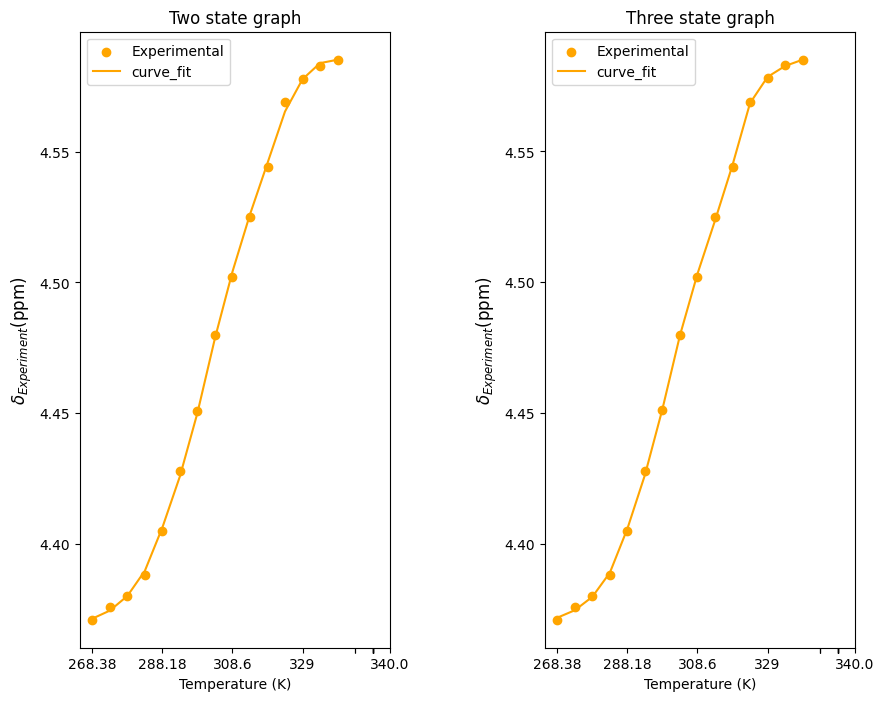

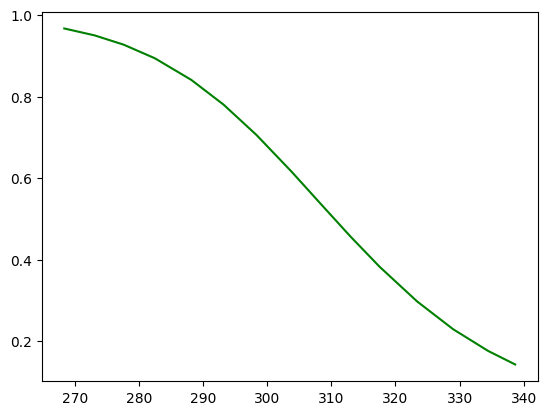

[4.21022612 4.13606458 4.03732397 3.89165585 3.66114278 3.39814637
 3.07289272 2.681772   2.31851398 1.98712466 1.66491328 1.29453555
 0.99826228 0.76650759 0.62189441]


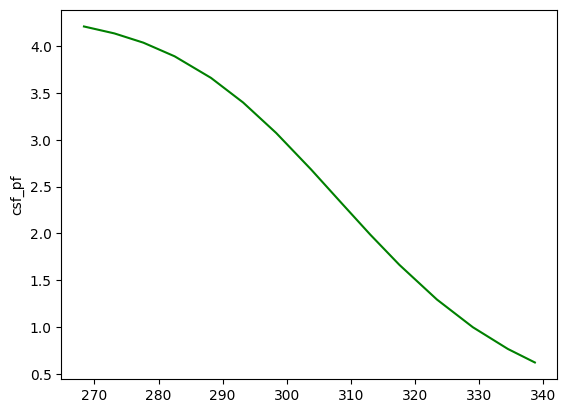

[0.1595625  0.24168604 0.35102748 0.51233459 0.76759562 1.05882742
 1.41900042 1.852112   2.25436952 2.62133692 2.97814104 3.38828264
 3.71636392 3.97299988 4.13313878]


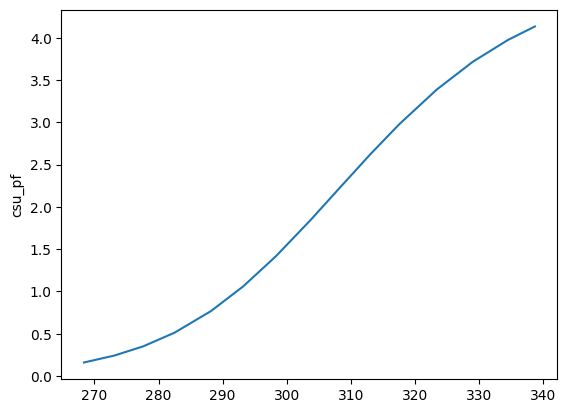

[4.36978862 4.37775063 4.38835145 4.40399043 4.4287384  4.45697379
 4.49189314 4.533884   4.57288351 4.60846158 4.64305431 4.6828182
 4.7146262  4.73950747 4.75503319]


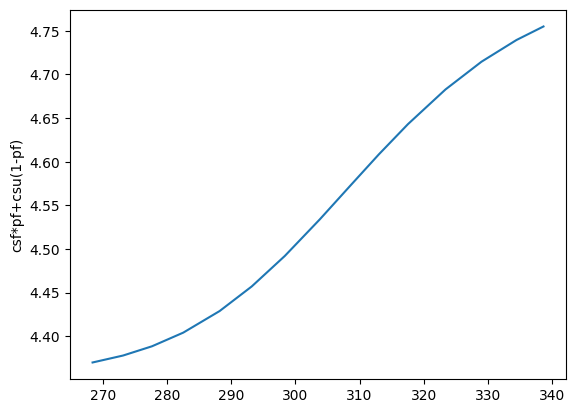

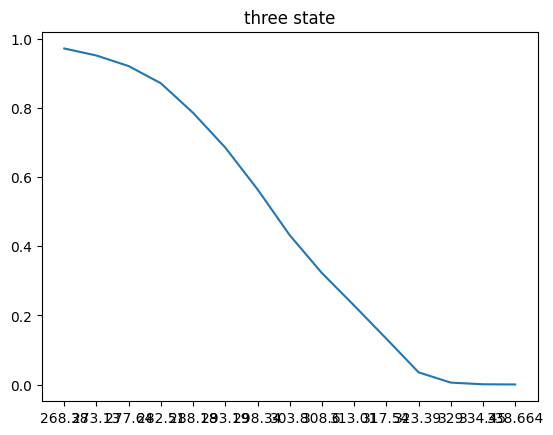

In [30]:
#selected experimental fitting
import scipy.optimize as optimize
import math
import statistics
import scipy
from scipy.optimize import differential_evolution

temp_exp_float=[]
melting_exp=[]
data_exp={}
def chi_square(pred,exp,perr):
    total = 0
    return(np.sum(((pred-exp)/statistics.stdev(pred-exp))**2))
        
        

    #cs = (cs_f )*(1/(1+np.exp((-dH +((i*dH)/Tm))/R*i)))+(1-(1/(1+np.exp((-dH +((i*dH)/Tm)/R*i)))))*(cs_u)

#def residuals_Mun(temp_exp_float,cs_f,cs_f_slope,cs_u,cs_u_slope,Tm,dH,shifts):
    #return shifts - two_state_func_Mun(temp_exp_float,cs_f,cs_f_slope,cs_u,cs_u_slope,Tm,dH)
for i in range(0,len(temp_exp)):
    temp_exp_float.append(float(temp_exp[i]))
parameters_exp ={}
residue_exp =collections.defaultdict(dict)  
resid=[33]
l = 0

for item in resid:
    print(resid[l])
    

    shifts = []
    
    for f in temp_exp:
        shifts.append(exp_data[str(item)][str(f)][0])
        
    print(shifts)
    shifts = np.array(shifts)
    temp_exp_float = np.array(temp_exp_float)
    shifts = shifts.astype(dtype=np.float64)
    temp_exp_float = temp_exp_float.astype(dtype=np.float64)
    min_cs = (np.mean(shifts[:5]))
    max_cs = np.mean(shifts[-5:])
   

    lower_bounds_2 = [
        min_cs-0.25,   # cs_f
        -0.01,           # cs_f_slope
        max_cs - 0.25,   # cs_u
        -0.01,           # cs_u_slope
        270,          # Tm
        0            # dH (kcal/mol)
    ]

    upper_bounds_2 = [
        min_cs + 0.25,   # cs_f
        +0.01,           # cs_f_slope
        max_cs+0.25,   # cs_u
        +0.01,           # cs_u_slope
        330,          # Tm
        100           # dH
    ]


    lower_bounds = [
        min_cs - 0.25,  # cs_f
        -0.015,          # cs_f_slope
        max_cs - 0.25,  # cs_u
        -0.015,          # cs_u_slope
        268,         # Tm1 (K)
        5,         # Tm2 (K)
        0,          # dH1 (kcal/mol)
        0,          # dH2 (kcal/mol)
        np.mean(shifts)-0.3    # cs_i
    ]

    upper_bounds = [
        min_cs + 1,  # cs_f
        +0.015,          # cs_f_slope
        max_cs +0.1,  # cs_u
        +0.015,          # cs_u_slope
        330,         # Tm1
        70,         # Tm2
        100,         # dH1
        100,         # dH2
        np.mean(shifts)+0.3    # cs_i
    ]
    p0_2 = [
    shifts[0],        # cs_f
    0.0,              # slope folded
    shifts[-1],       # cs_u
    0.0,              # slope unfolded
    303.0,            # Tm
    12.0             # dH in kcal/mol
    ]


    p0_3 = [
    shifts[0],        # cs_f
    0,                # cs_f_slope
    shifts[-1],       # cs_u
    0,                # cs_u_slope
    295,              # Tm1 (K)
    5,              # Tm2 (K)
    20,               # dH1 (kcal/mol)
    20,              # dH2 (kcal/mol)
    np.mean(shifts)   # cs_i 
    ]
    def sumOfSquaredError_two(parameterTuple):
        val = two_state_func_Mun(temp_exp_float, *parameterTuple)
        #print(val)
        return(np.sum((shifts-val)**2))
    def sumOfSquaredError_three(parameterTuple):
        val = three_state_func_Mun(temp_exp_float, *parameterTuple)
        #print(val)
        return(np.sum((shifts-val)**2))
    
    def generate_Initial_Parameters_two():

        parameterBounds = []
        parameterBounds.append([3., 4.19]) # search bounds for a
        parameterBounds.append([-0.1, +0.1]) # search bounds for b
        parameterBounds.append([min(shifts), max(shifts)]) # search bounds for offset
        parameterBounds.append([-0.1, +0.1])
        parameterBounds.append([300, 306])
        parameterBounds.append([0, 100])

        #parameterBounds = np.array(parameterBounds)
        # "seed" the numpy random number generator for repeatable results
        result = differential_evolution(sumOfSquaredError_two, parameterBounds, tol=0.000001)
        return result.x
    def generate_Initial_Parameters_three():
        parameterBounds = []
        parameterBounds.append([min(shifts), max(shifts)]) # search bounds for a
        parameterBounds.append([-0.1, +0.1]) # search bounds for b
        parameterBounds.append([min(shifts), max(shifts)]) # search bounds for offset
        parameterBounds.append([-0.1, +0.1])
        parameterBounds.append([268, 300])
        parameterBounds.append([300, 330])
        parameterBounds.append([0, 100])
        parameterBounds.append([0, 100])
        parameterBounds.append([min(shifts), max(shifts)])

        #parameterBounds = np.array(parameterBounds)
        # "seed" the numpy random number generator for repeatable results
        result = differential_evolution(sumOfSquaredError_three, parameterBounds,  tol=0.000001)
        return result.x
    geneticParameters_two = generate_Initial_Parameters_two()
    geneticParameters_three = generate_Initial_Parameters_three()
    #popt_two, pcov_two=  optimize.curve_fit(two_state_func_Mun,xdata=temp_exp_float,ydata = shifts,p0=geneticParameters_two,maxfev=1000000,bounds=((3,-0.1,3,-0.1,300,0),(5,+0.1,5,+0.1,307,100)))

    #popt_two, pcov_two=  optimize.curve_fit(two_state_func_Mun,xdata=temp_exp_float,ydata = shifts,p0=[min(shifts),-2.05097266e-03,max(shifts),-2.05097266e-03,304.0,15],maxfev=1000000,bounds=((3,-0.1,3,-0.1,300,0),(5,+0.1,5,+0.1,320,100)),method='trf')

    popt_two, pcov_two=  optimize.curve_fit( two_state_func_Mun,xdata=temp_exp_float,ydata = shifts,p0=p0_2,maxfev=1000000,bounds=(lower_bounds_2,upper_bounds_2))
    popt_three, pcov_three=  optimize.curve_fit(three_state_func_Mun,xdata=temp_exp_float,ydata = shifts,p0=p0_3,maxfev=1000000,bounds=(lower_bounds,upper_bounds),absolute_sigma=True)
    #popt_three, pcov_three=  optimize.curve_fit(three_state_func_Mun,xdata=temp_exp_float,ydata = shifts,p0=geneticParameters_three,maxfev=1000000,bounds=((min(shifts),-0.1,min(shifts),-0.1,268,300,0,0,min(shifts)),(max(shifts),+0.1,max(shifts),+0.1,330,330,100,100,max(shifts))))
   
    print('resid', i)
    
    #print(*popt)
    #print(pcov)
    perr_two = np.sqrt(np.diag(pcov_two))
    perr_three = np.sqrt(np.diag(pcov_three))

    
    print('perr_two',perr_two)
    print('perr_three',perr_three)
        
    
    #p_value = 1 - scipy.stats.f.cdf(F, df1, df2)
    #print(F,p_value)
    
    fit_two = two_state_func_Mun(temp_exp_float,*popt_two)
    fit_three = three_state_func_Mun(temp_exp_float,*popt_three)
    ss1 = np.sum((shifts-fit_two)**2)
    

    ss2 = np.sum((shifts-fit_three)**2)
    df1=len(temp_exp)-6
    df2=len(temp_exp)-8
    F = ((ss1-ss2)/(df1-df2))/(ss2/df2)
    p_value = 1 - scipy.stats.f.cdf(F, df1, df2)
    print('F',F)
    print('p',p_value)
    print('ss1',ss1)
    print('ss2',ss2)
    print('parameters two state',popt_two)
    print('Tm two state', popt_two[4])
    print('dH two state', popt_two[5])
    print('Tm three state', popt_three[4],popt_three[5])
    print('dH three state', popt_three[6],popt_three[7])

    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10, 8))

    #print('resid', resid[l],data[f'Tm1_{resid[l]}'])
    if (l==0):
        data_exp[f'dH1_{resid[l]}']=popt_two[5]
        data_exp[f'Tm1_{resid[l]}']=popt_two[4]
        data_exp[f'dH1_err{resid[l]}']=perr_two[5]
        data_exp[f'Tm1_err{resid[l]}']=perr_two[4]


    elif (l>0) and (resid[l-1]==resid[l]):
        data_exp[f'dHA2_1_{resid[l]}']=popt_two[5]
        data_exp[f'TmA2_1_{resid[l]}']=popt_two[4]
        data_exp[f'dH1_err{resid[l]}']=perr_two[5]
        data_exp[f'Tm1_err{resid[l]}']=perr_two[4]

    else:

        data_exp[f'dH1_{resid[l]}']=popt_two[5]
        data_exp[f'Tm1_{resid[l]}']=popt_two[4]
        data_exp[f'dH1_err{resid[l]}']=perr_two[5]
        data_exp[f'Tm1_err{resid[l]}']=perr_two[4]





    ax1.scatter(temp_exp,shifts,label='Experimental',color='orange')
    ax2.scatter(temp_exp,shifts,label='Experimental',color='orange')
    ax1.plot(temp_exp,fit_two,label='curve_fit',color='orange')
    ax1.set_title('Two state graph')
    ax2.set_title('Three state graph')

    ax2.plot(temp_exp,fit_three,label='curve_fit',color='orange')


    ticks=[]
    #ax.set_xticks(range(len(temp_exp)))
    #ax1.set_xlabel(['268.38',' ','',' ','288.18','','','','308.6','','317.54','','','','338.664'])
    ax1.set_xticks(['268.38',' ','',' ','288.18','','','','308.6','','','','329','','','','340.0'])
    #ax1.set_xticks(temp_exp)
    #ax2.set_xlabel(['268.38',' ','',' ','288.18','','','','308.6','','','329','','','338.664'], rotation=45, ha='right')
    ax2.set_xticks(['268.38',' ','',' ','288.18','','','','308.6','','','','329','',' ','','340.0'])
    ax1.set_xlabel('Temperature (K)')
    ax2.set_xlabel('Temperature (K)')

    #ax1.set_ylabel('')
    ax1.set_ylabel(r'$δ_{Experiment}$(ppm)',fontsize=12)
    ax2.set_ylabel(r'$δ_{Experiment}$(ppm)',fontsize=12)
    ax1.legend()
    ax2.legend()
    #plt.savefig(f'/blue/colina/dkodituwakku/plots-twostate-three-state/state-{i}-exp.jpg',dpi=300)

    #plt.ylabel(r'$δ_{Predicted}$ (ppm)',fontsize=12)

    #plt.plot(temp_exp,fit)
    plt.subplots_adjust(wspace = 0.5)
    extent = ax2.get_window_extent().transformed(fig.dpi_scale_trans.inverted())

    fig.savefig(f'/blue/roitberg/dkodituwakku/plots-thesis/plots-twostate-{l}-experiment.jpg', bbox_inches=extent.expanded(2.0, 1.5),dpi=300)
    plt.show()
    plt.plot(temp_exp_float,plot_pf_two(temp_exp_float,*popt_two),color='green')

    plt.show()
    plt.ylabel('csf_pf')
    plt.plot(temp_exp_float,plot_csf_pf(temp_exp_float,*popt_two),color='green')
    print(plot_csf_pf(temp_exp_float,*popt_two))
    plt.show()
    plt.ylabel('csu_pf')         
    plt.plot(temp_exp_float,plot_csu_pf(temp_exp_float,*popt_two))
    print(plot_csu_pf(temp_exp_float,*popt_two))
    plt.show()
    plt.ylabel('csf*pf+csu(1-pf)') 

    plt.plot(temp_exp_float,plot_csf_csu_pf(temp_exp_float,*popt_two))
    print(plot_csf_csu_pf(temp_exp_float,*popt_two))
    plt.show()
    plt.title('three state')
    plt.plot(temp_exp,plot_pf_three(temp_exp_float,*popt_three))

    plt.show()
        
        
   
    l = l+1 



195 5
two state
Tm two state 353.3471589513269
dH two state 10.327497767584846
Tm three state 319.56679407206224 12.548430874206444
dH three state 54.603774576608714 60.65810101094327
0.0007368809375631003 0.0008662096363731209
cs_f 4.114673419765809


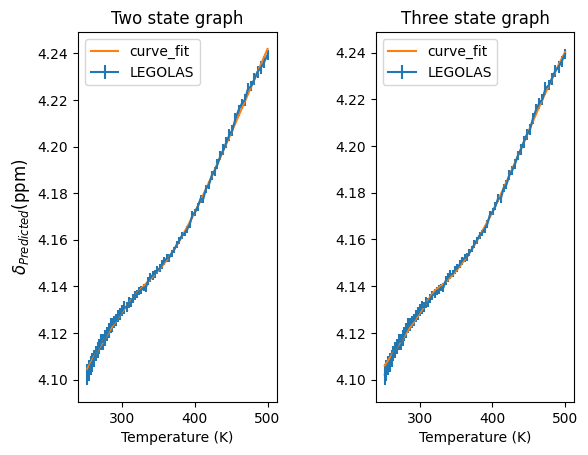

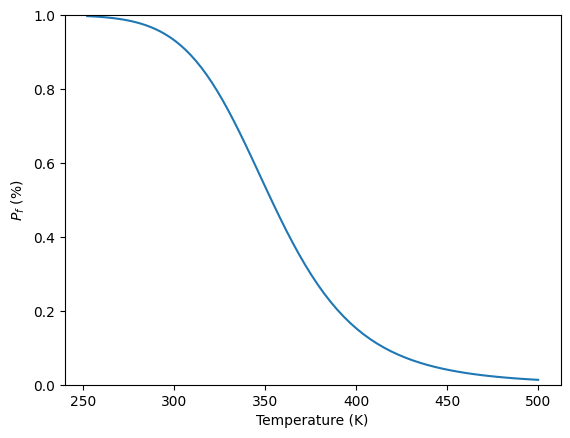

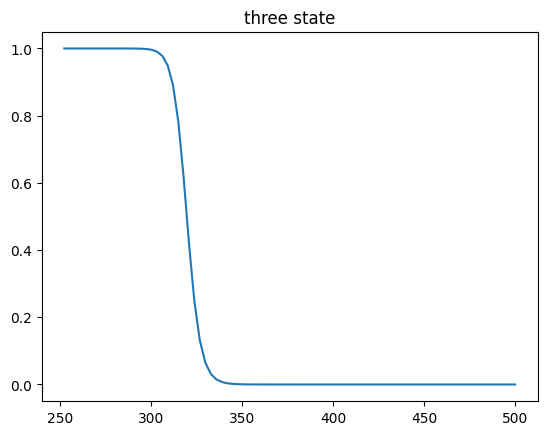

196 6
two state
Tm two state 499.9999999999089
dH two state 8.061601872946252
Tm three state 307.4185973219294 49.99999999999936
dH three state 10.280513061599743 17.515327836841042
0.0011119690721983785 0.0007706067340269011
cs_f 3.7387915083596495


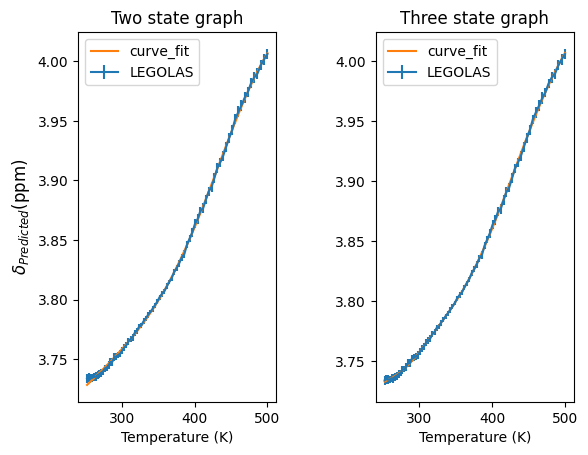

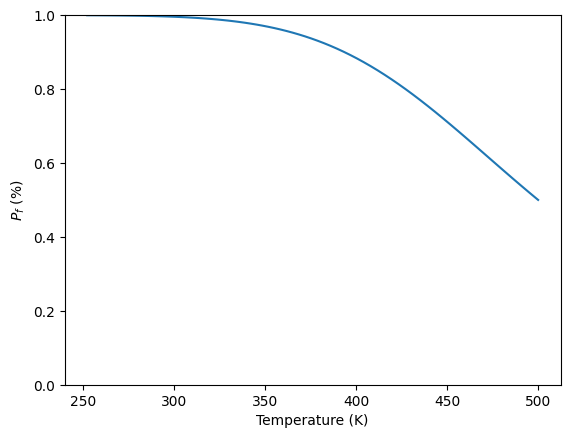

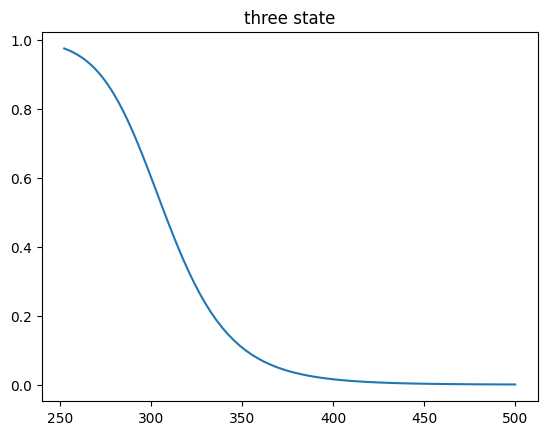

197 7
two state
Tm two state 394.2523979648036
dH two state 10.61026726631711
Tm three state 349.99065019177164 26.547502420570492
dH three state 21.353517672457333 32.84225135912176
0.0013514687989772747 0.0008049565859119075
cs_f 3.980176951560255


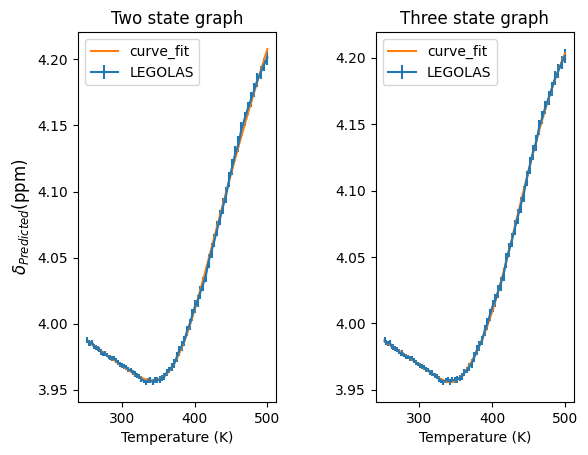

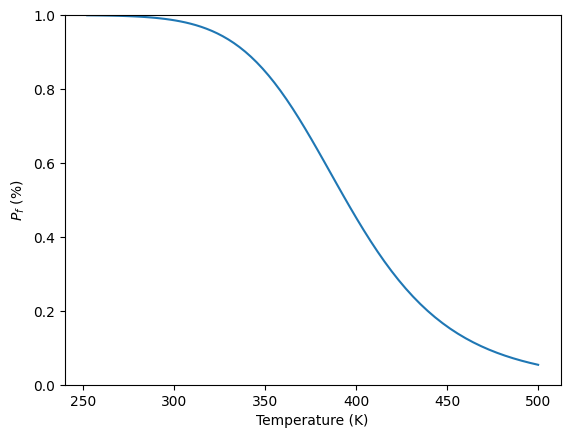

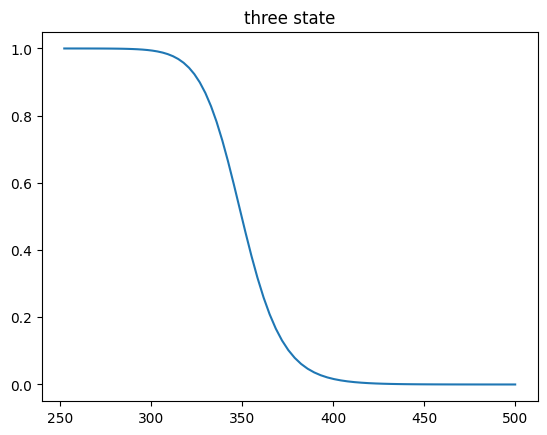

198 8
two state
Tm two state 363.76406776835904
dH two state 9.180601768820521
Tm three state 321.8305414603351 37.20830414469757
dH three state 17.825389323751207 26.097821907185242
0.0007742924161450422 0.0005144762291756422
cs_f 4.1006778481552155


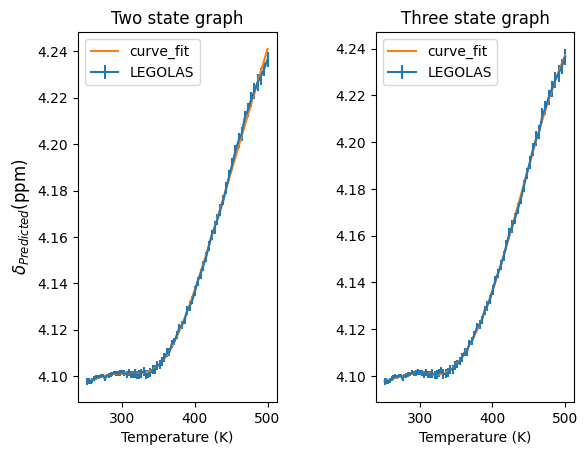

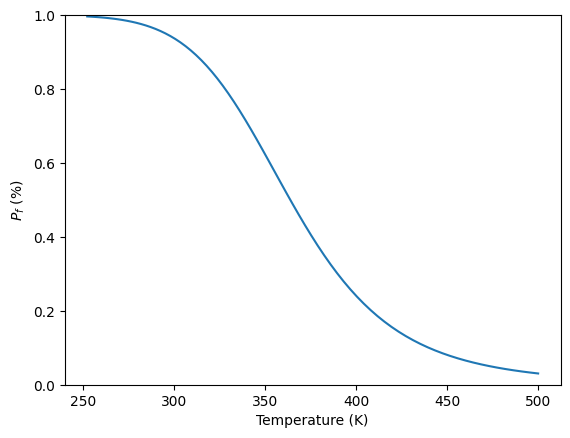

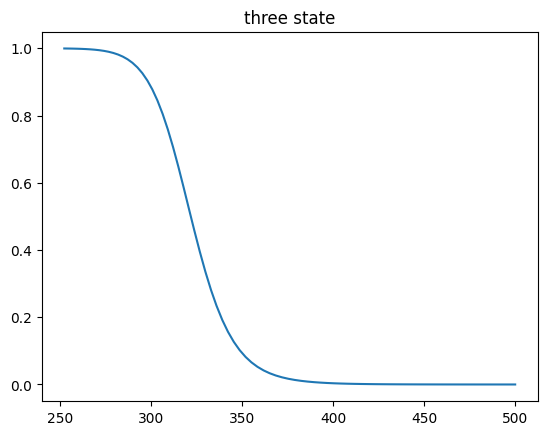

199 9
two state
Tm two state 367.3512845369216
dH two state 8.126849240658743
Tm three state 324.90734578800715 48.040492175409625
dH three state 13.408534044931777 22.75340160246136
0.000842767507288625 0.000432404024734178
cs_f 4.120906031762538


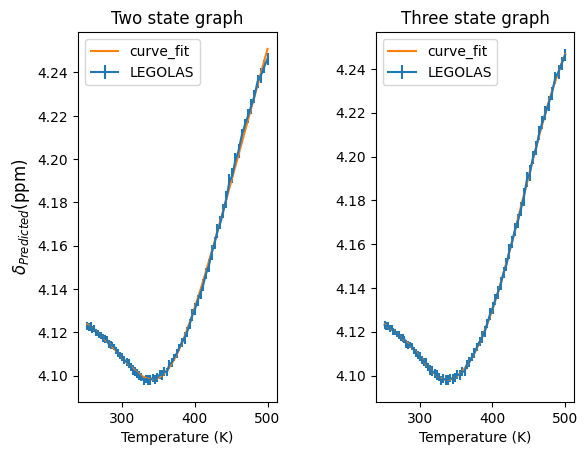

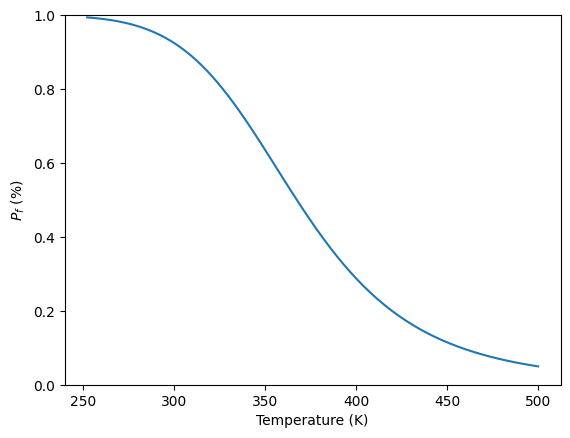

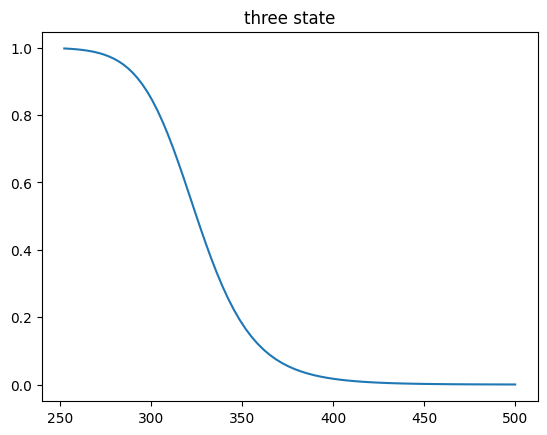

200 10
two state
Tm two state 460.0431014026537
dH two state 4.606628070450999
Tm three state 349.99952907507964 46.33352287775076
dH three state 10.152970335901248 19.991173078402372
0.0012543906412223057 0.0006453274988436182
cs_f 3.943294975563629


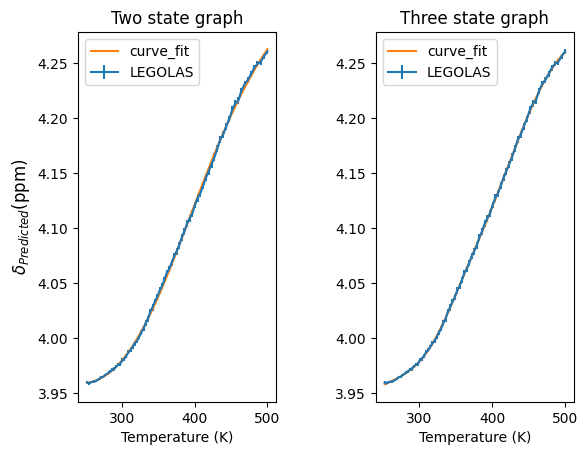

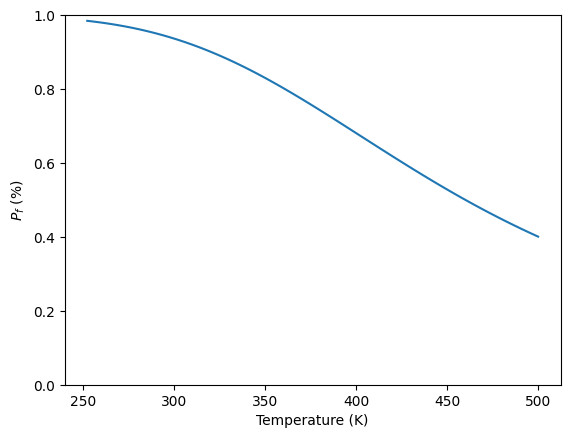

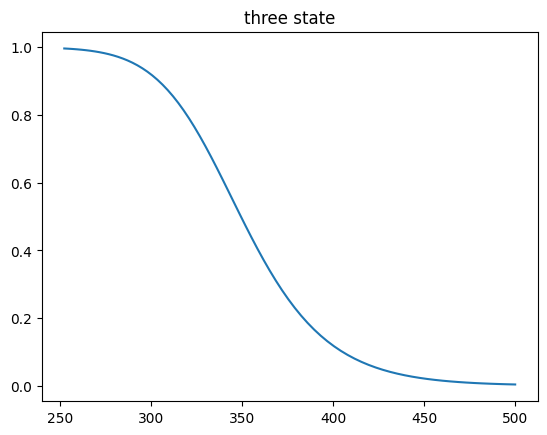

201 11
two state
Tm two state 347.4311645735536
dH two state 14.234532689211278
Tm three state 331.25947296936647 40.58643581336573
dH three state 13.53843394213475 20.824289133697242
0.0007596895650638421 0.0003823248698664017
cs_f 4.175458834849087


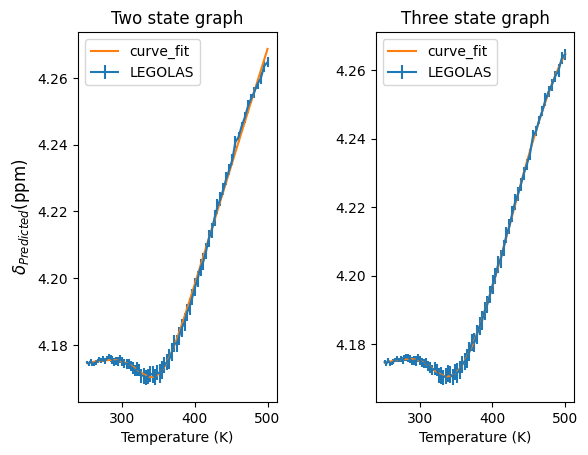

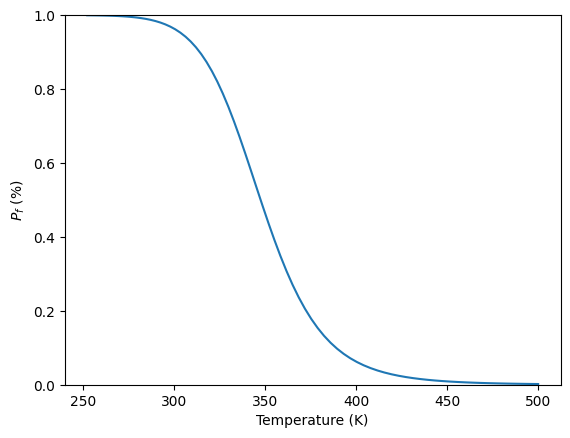

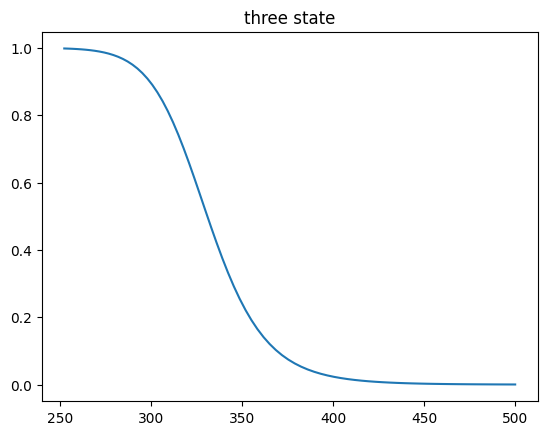

202 12
two state
Tm two state 370.22286102891127
dH two state 5.118696107973842
Tm three state 347.2239613654722 40.932361145281114
dH three state 10.221856901739116 22.432849779683792
0.0008295554245459513 0.00045506360601101173
cs_f 4.069206719198961


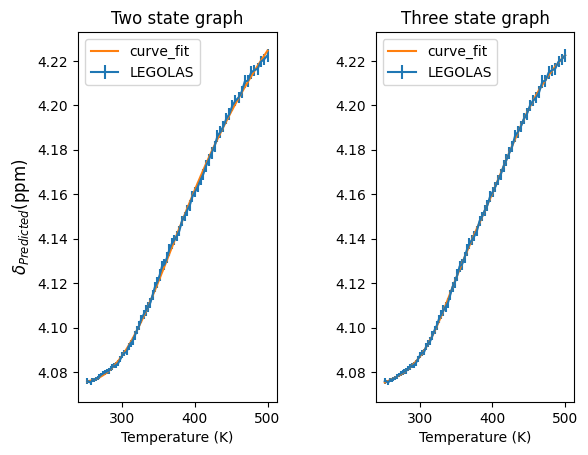

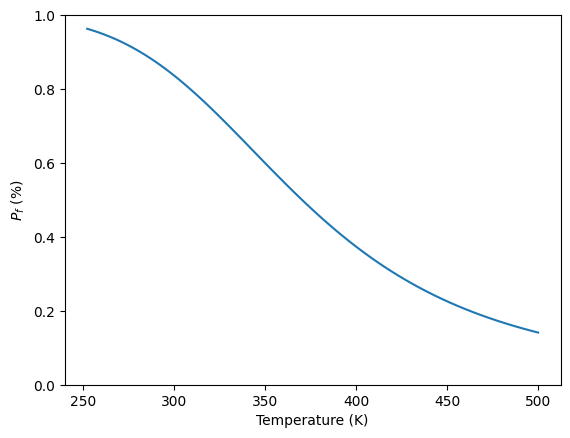

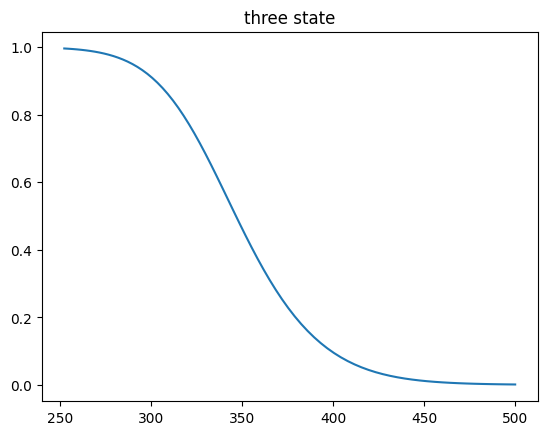

203 13
two state
Tm two state 329.8524812071309
dH two state 9.648399234743053
Tm three state 313.6427190987722 24.646875573160404
dH three state 10.000310288394855 22.921974064449557
0.0009896579930275587 0.000822020014583759
cs_f 4.712776843975751


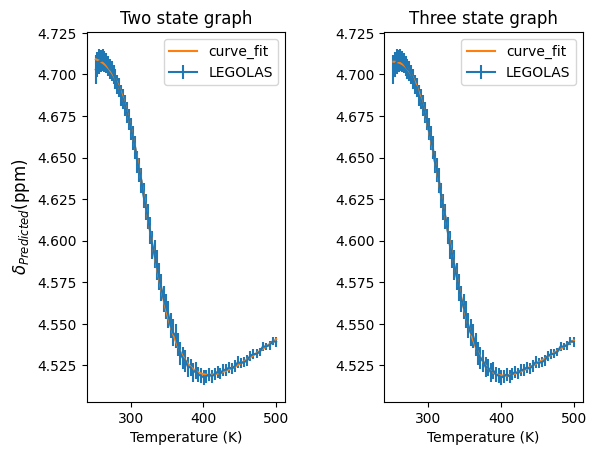

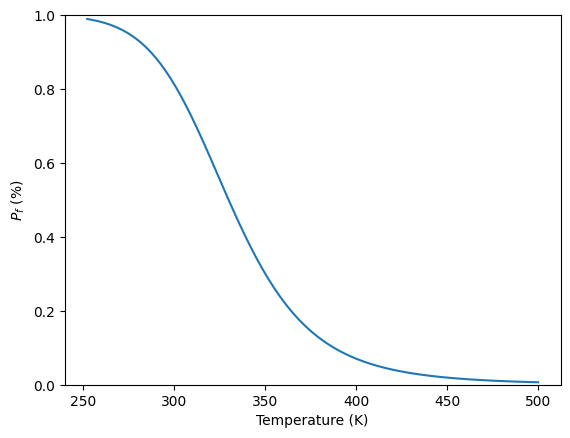

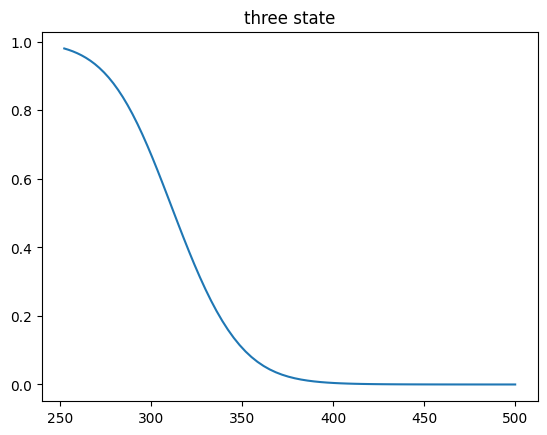

204 14
two state
Tm two state 346.48655174204254
dH two state 7.734274546351667
Tm three state 339.76492250209003 31.871299201875853
dH three state 10.00011461654281 17.28051043674545
0.0008573828049962629 0.0006880072887537025
cs_f 4.321890268816426


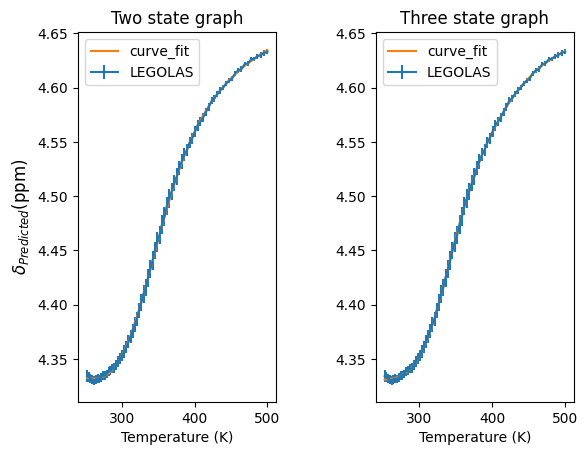

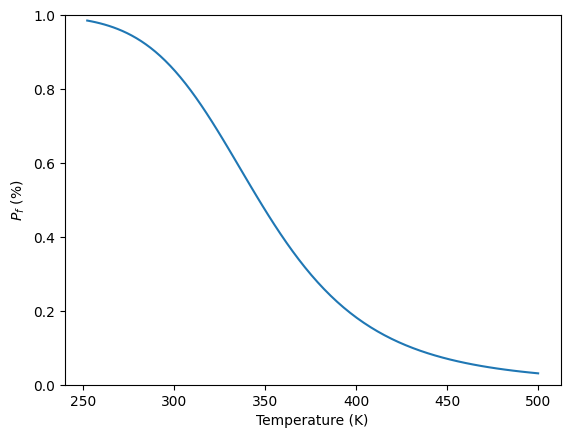

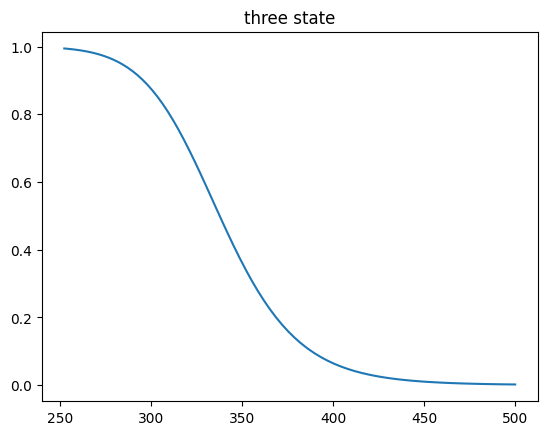

205 15
two state
Tm two state 341.2979893283082
dH two state 8.371956421831062
Tm three state 329.8981613287484 32.387261577561965
dH three state 10.000763906170684 17.705668063926428
0.0008237488092367566 0.0007622204937586829
cs_f 4.380343094545184


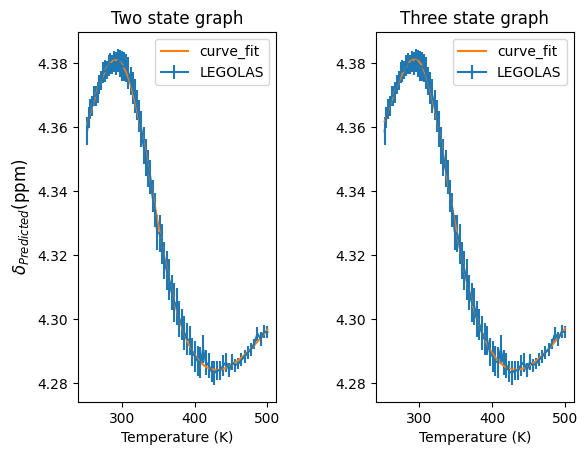

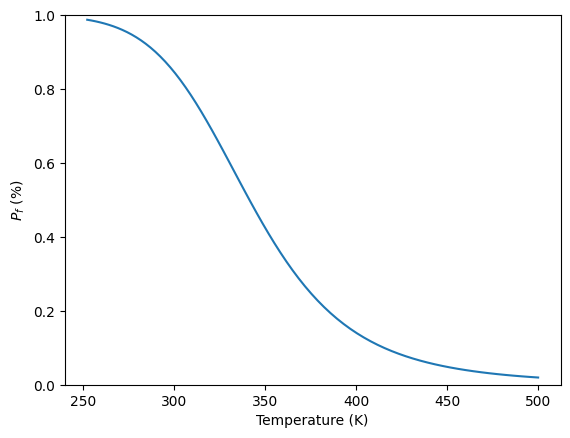

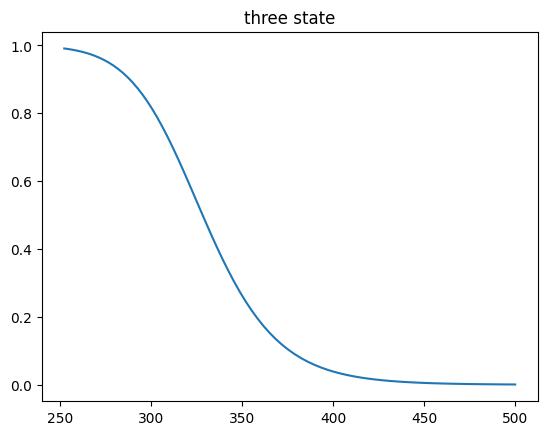

206 16
two state
Tm two state 321.46859222325776
dH two state 8.361846822483685
Tm three state 280.0098597456477 23.806307058514996
dH three state 10.00159846047505 19.26819147000713
0.0009181243448760176 0.0008879603956773015
cs_f 4.676322082683733


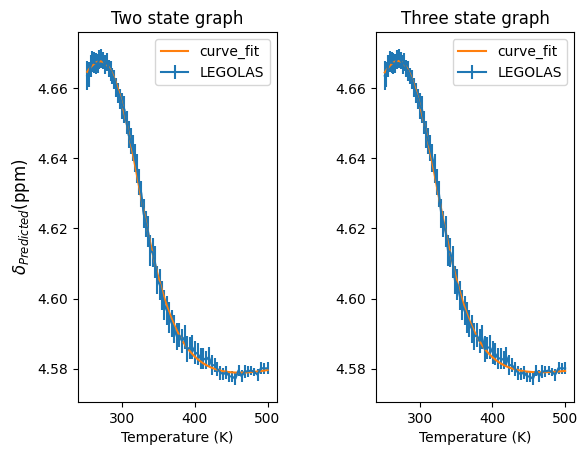

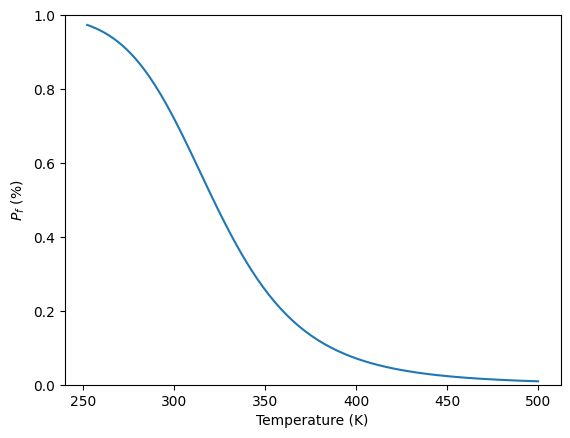

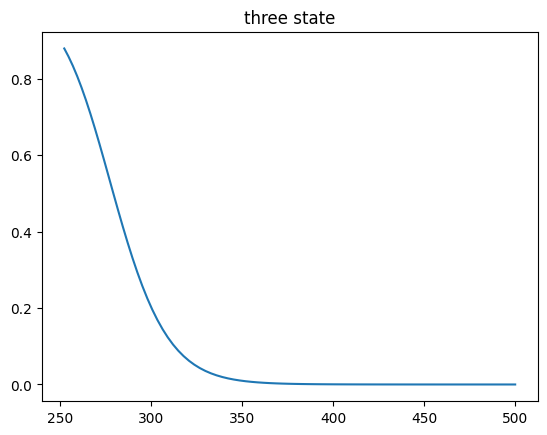

207 17
two state
Tm two state 324.3058655205481
dH two state 8.682420222853873
Tm three state 331.9134525432305 46.24704258294748
dH three state 10.000000000000043 21.353045209439085
0.0008726267603294129 0.000682017234991837
cs_f 4.004414272984264


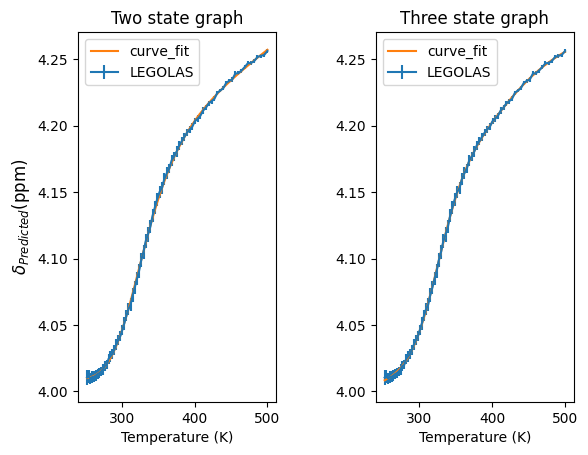

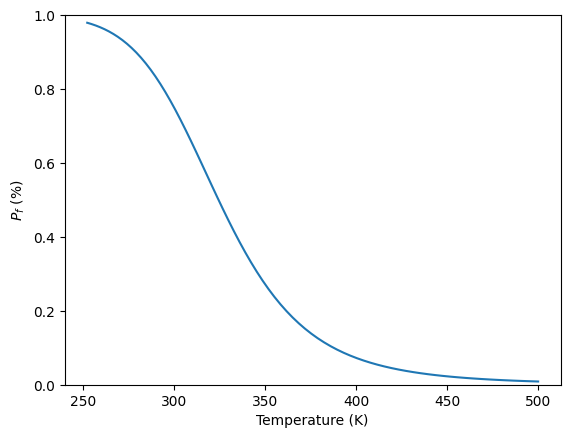

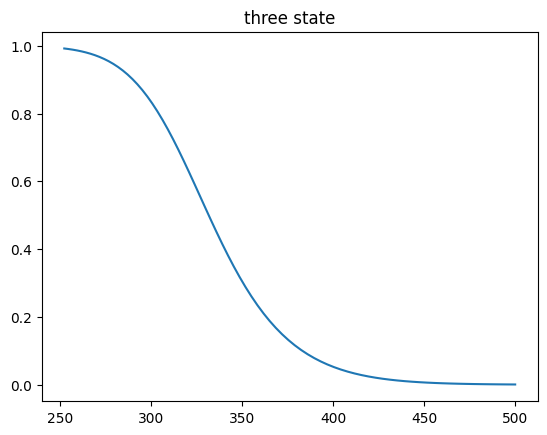

208 18
two state
Tm two state 326.9888867999283
dH two state 9.571642109901319
Tm three state 312.18562127759594 10.925750206338805
dH three state 10.000000001630454 18.96093554407992
0.00047377416261994653 0.0004698158348366614
cs_f 4.25814659087079


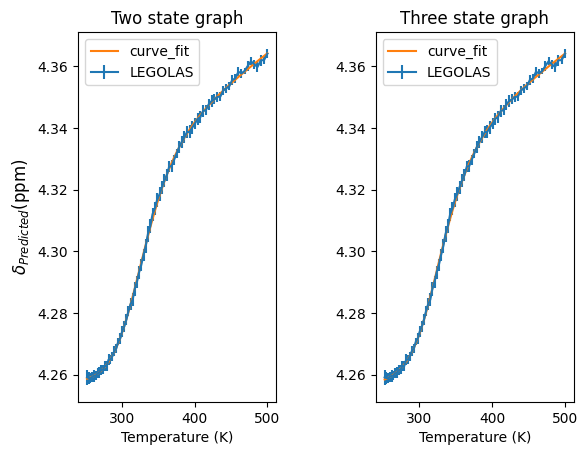

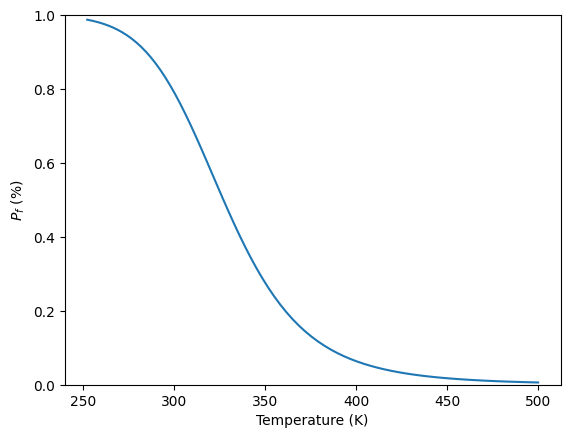

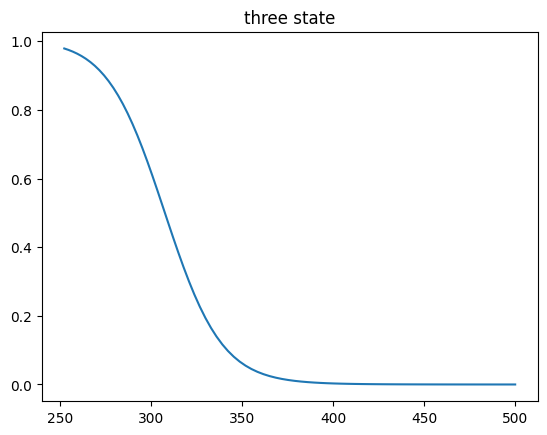

209 19
two state
Tm two state 333.2973610338478
dH two state 14.105322088824504
Tm three state 327.0728887436431 30.30033803880557
dH three state 11.642356697312106 20.655454155797845
0.0007578288775361604 0.0005507837042413162
cs_f 4.311844700925535


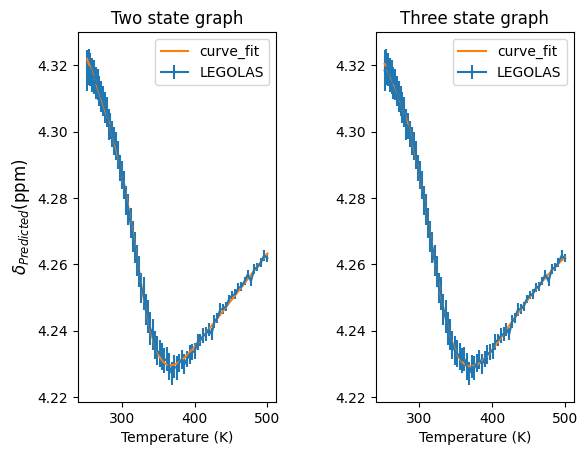

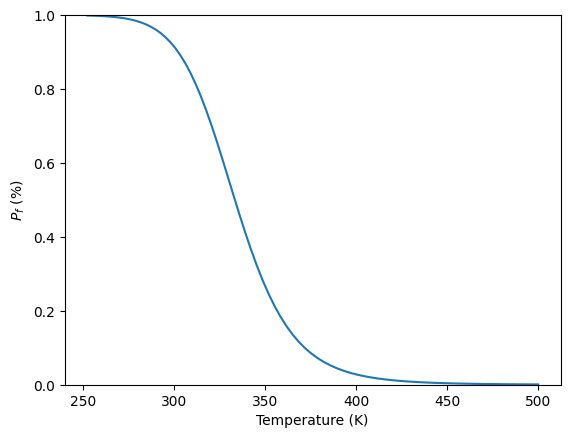

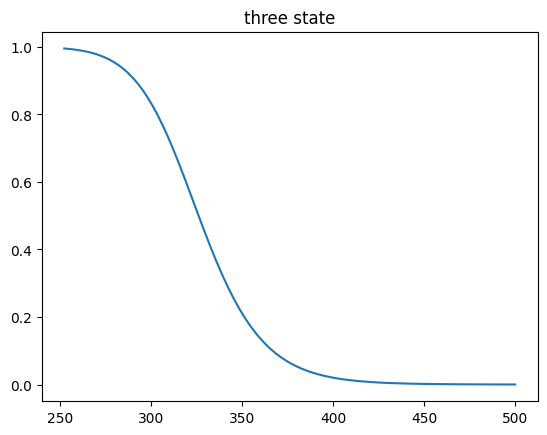

210 20
three state
Tm two state 325.8081695795148
dH two state 16.462459330531654
Tm three state 317.59663736567495 33.14296215150697
dH three state 10.522113831429952 22.534480742360767
0.0024896772564991093 0.0006854320822945563
cs_f 4.134425436777205


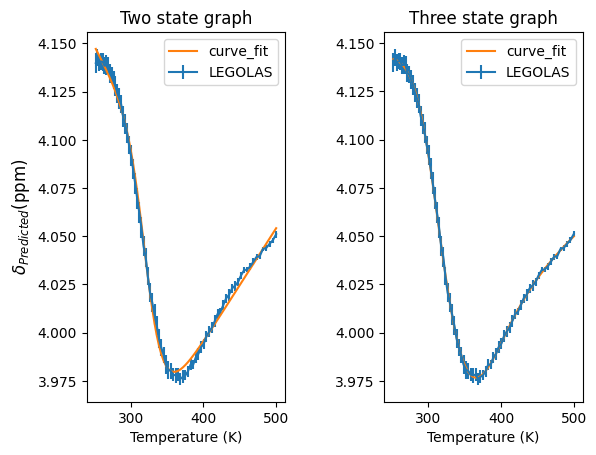

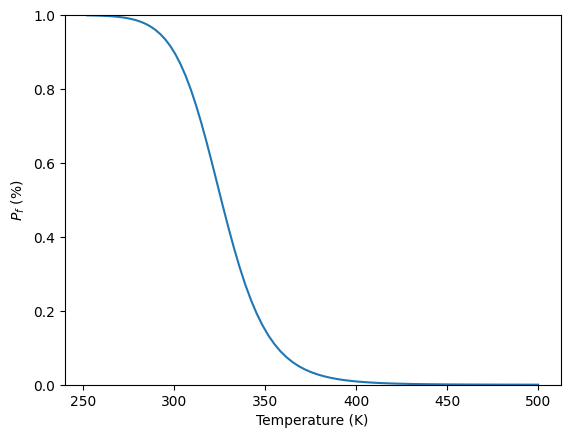

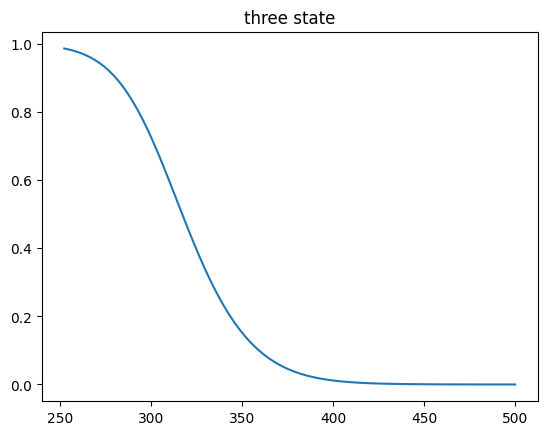

211 21
two state
Tm two state 321.2512604930078
dH two state 15.923330473342183
Tm three state 312.9376077058895 39.68824624142556
dH three state 10.000000000000002 28.346414363957628
17 amplitude too small
212 22
two state
Tm two state 325.9466094034104
dH two state 14.662618901415014
Tm three state 327.06000211219424 17.0412229744593
dH three state 10.000000000083794 18.21704163798789
0.0010837148850914601 0.0008104648542284683
cs_f 4.318661836143077


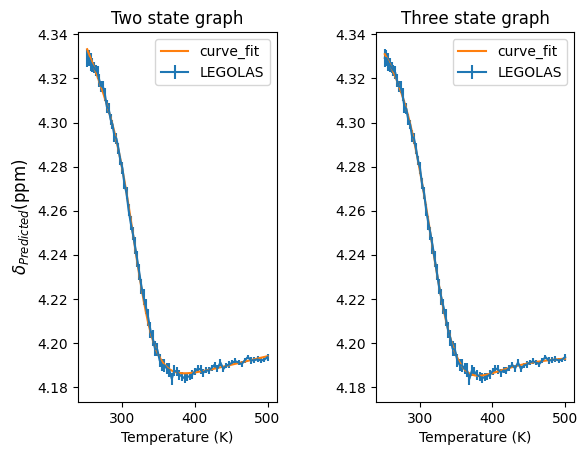

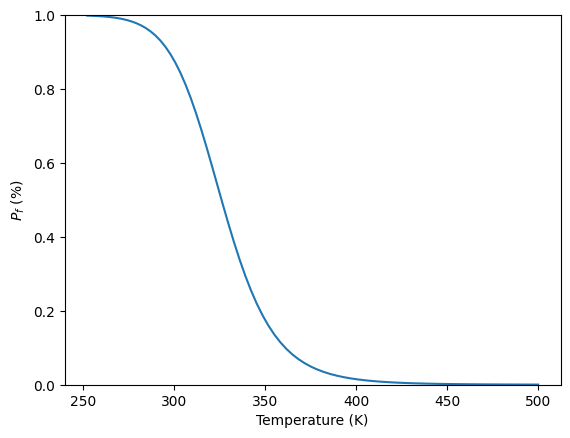

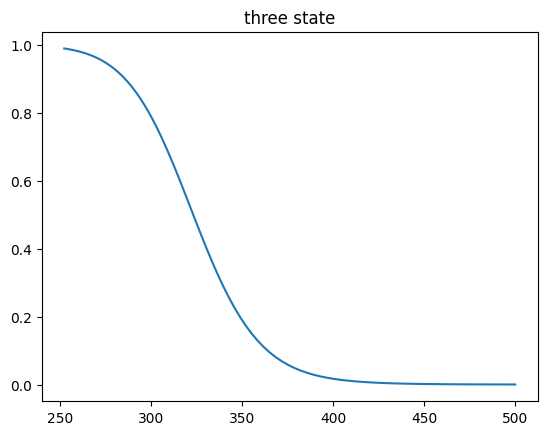

213 22
two state
Tm two state 326.7543671350142
dH two state 12.751014320740314
Tm three state 324.91280399446197 30.50352905746988
dH three state 10.049605963330844 19.044660116351068
0.0012009706024711047 0.0009260792365347707
cs_f 4.373901434328038


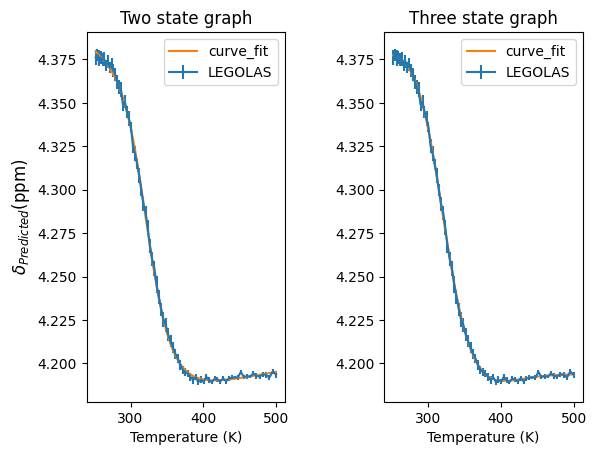

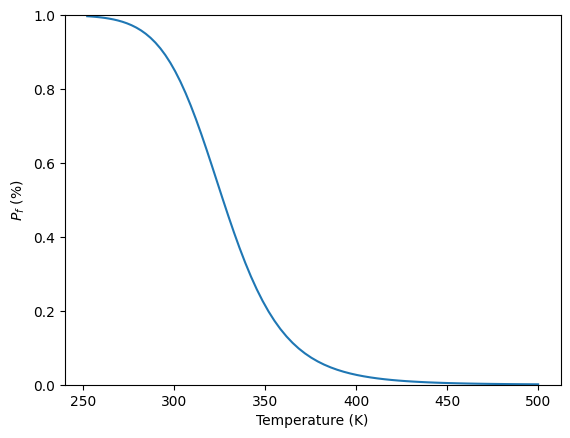

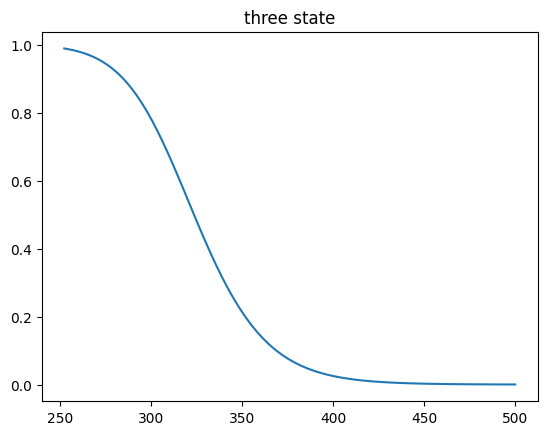

214 23
two state
Tm two state 327.00207787578535
dH two state 14.200919551442485
Tm three state 322.9556794864702 26.021043836562047
dH three state 14.122144395306972 71.35011871530273
0.000939146053619299 0.0007439623891786576
cs_f 4.45956525268977


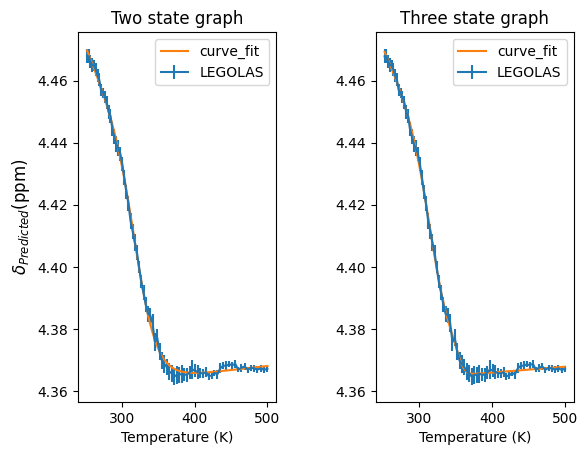

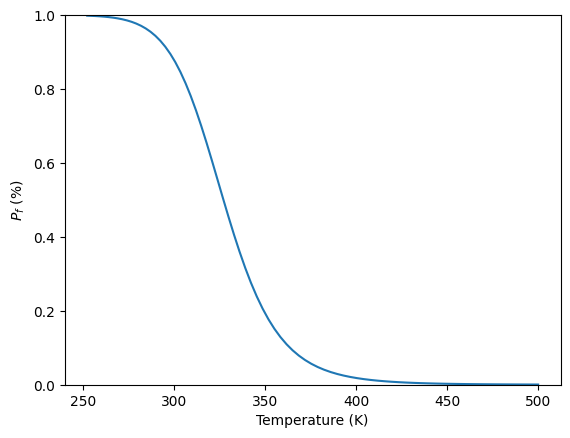

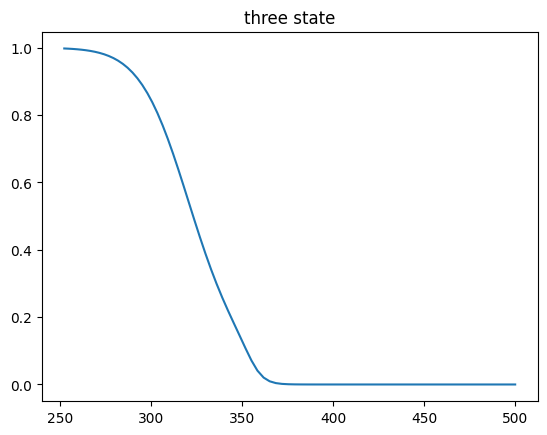

215 24
two state
Tm two state 334.2875875317956
dH two state 19.67233828629184
Tm three state 305.77636409018316 34.78327184765549
dH three state 10.000000000049383 78.5134689087378
21 amplitude too small
216 24
two state
Tm two state 328.1840479911699
dH two state 14.515335999809626
Tm three state 328.6875509814221 49.890911682430726
dH three state 10.501040865594497 34.47538216462578
22 amplitude too small
217 25
two state
Tm two state 334.3239577282247
dH two state 9.088904931692745
Tm three state 316.0217680076559 17.212089311723357
dH three state 10.318721118406534 21.513098370720012
0.0006497666158555937 0.000626831024849673
cs_f 3.886271003014207


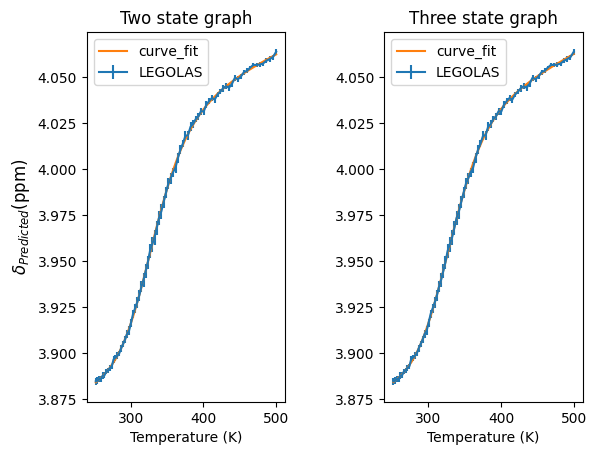

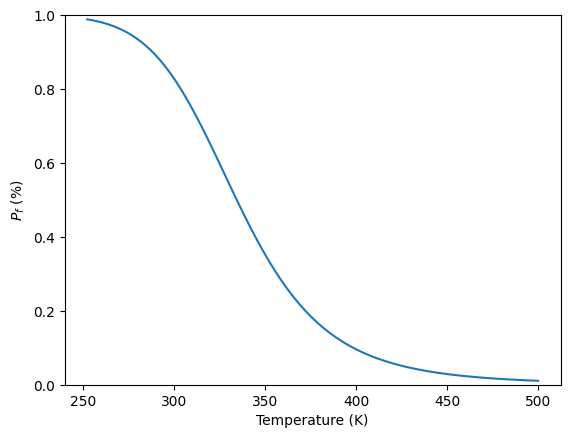

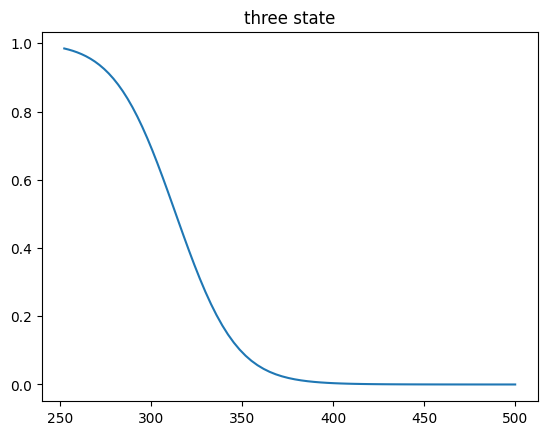

218 26
two state
Tm two state 331.0505133381656
dH two state 9.019459926421023
Tm three state 310.9598274646337 14.101823854484525
dH three state 10.000000031282408 18.448942570096808
0.0005939378632599338 0.0005838002322613415
cs_f 4.076784886400753


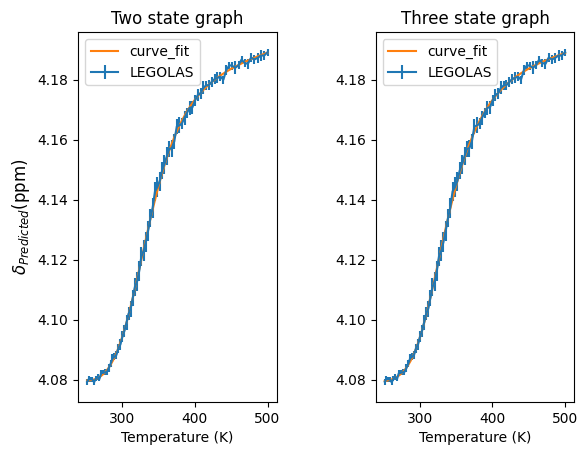

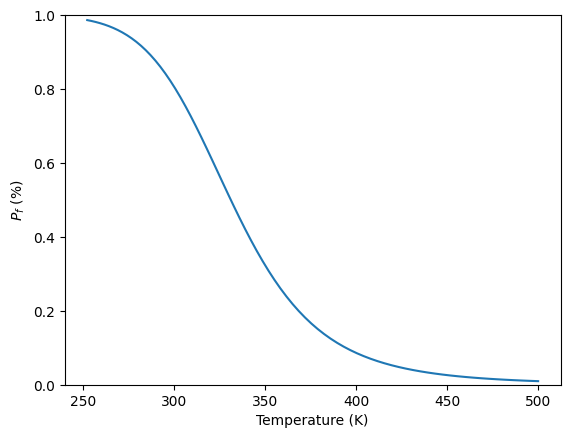

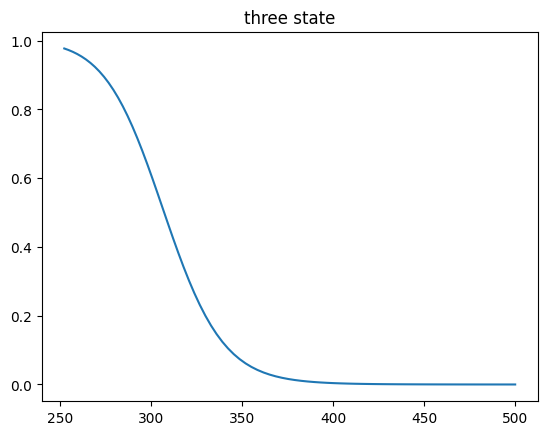

219 26
two state
Tm two state 328.4062025534638
dH two state 10.954269629408358
Tm three state 323.0034539878251 20.208032672943943
dH three state 10.000502831559107 23.12120687153929
0.000734300052100565 0.0006365848912639353
cs_f 3.990930610131923


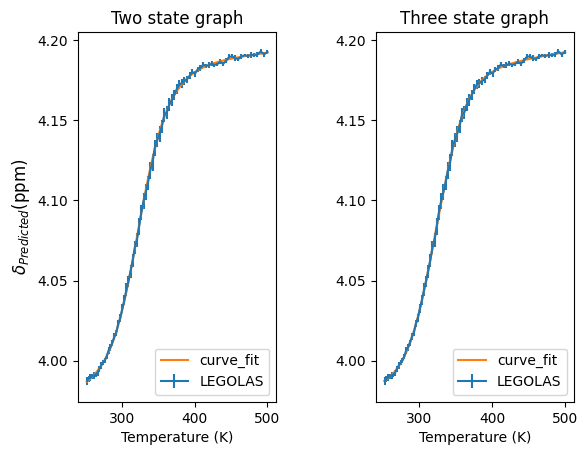

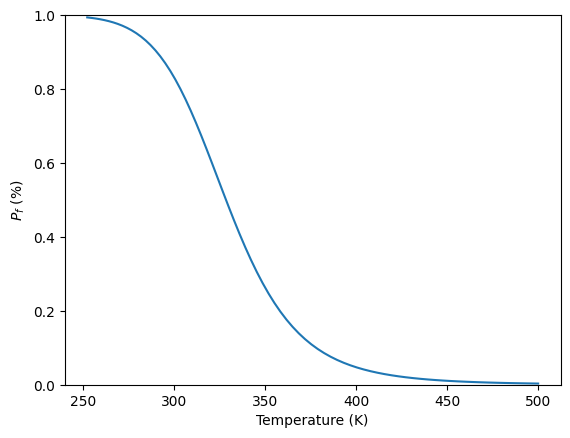

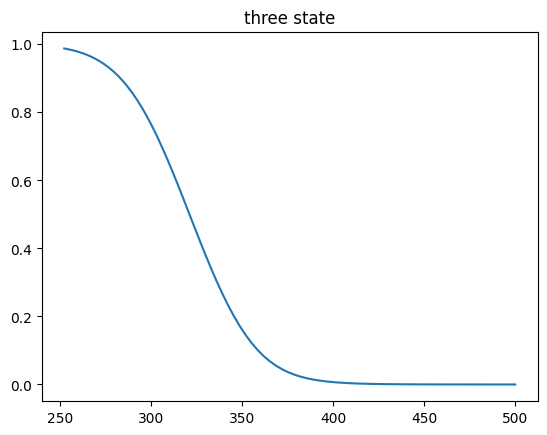

220 27
two state
Tm two state 331.0126042687913
dH two state 10.602679317804325
Tm three state 304.22528884337885 17.684952460652113
dH three state 10.005809956221826 21.84022254842581
0.0006265461702807921 0.0005962822727806838
cs_f 4.037753590151626


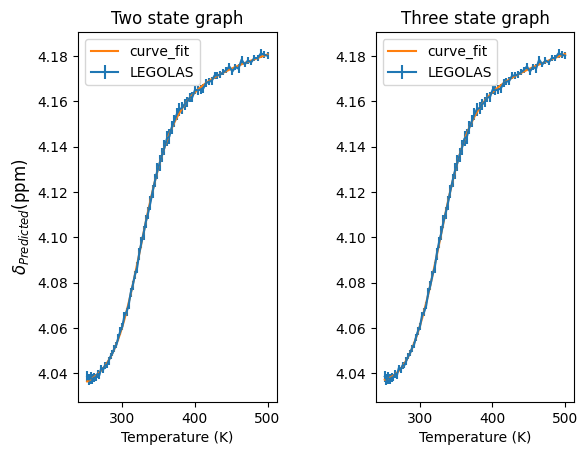

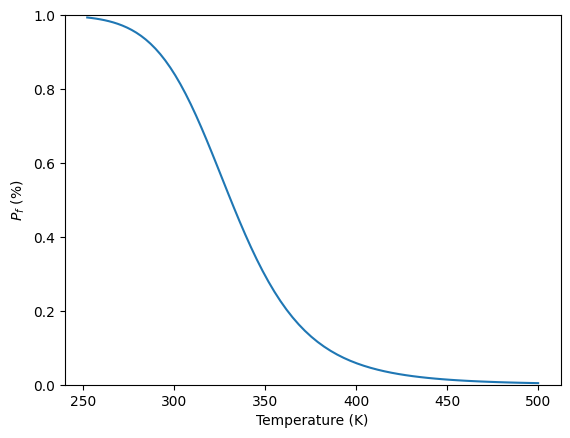

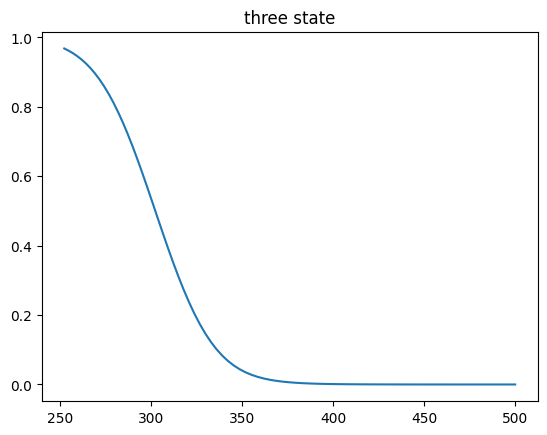

221 27
two state
Tm two state 331.98337875198183
dH two state 10.13714203233018
Tm three state 283.04863156541705 7.896959794254166
dH three state 45.233991275117845 55.550089780413394
0.0006713331650565498 0.00065896180414691
cs_f 4.048919756581227


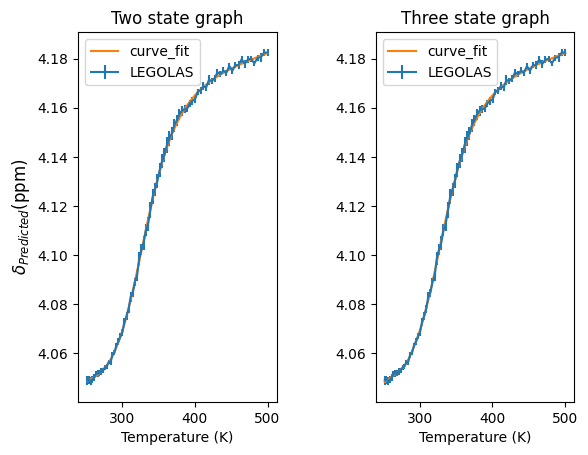

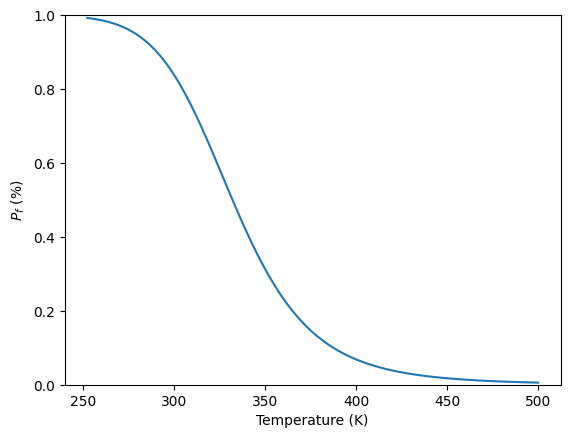

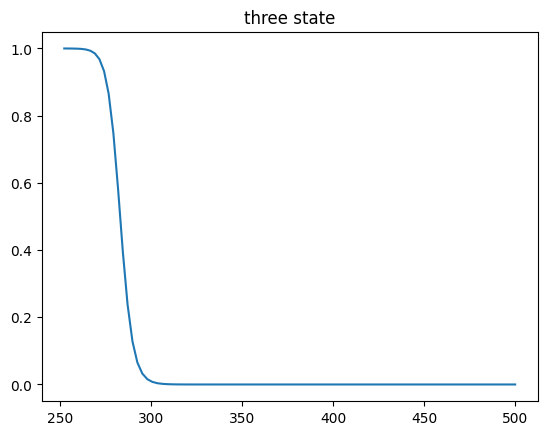

222 28
two state
Tm two state 321.69772420104283
dH two state 9.935527276755721
Tm three state 323.63817928256043 37.241292785004774
dH three state 12.51378084824907 99.65895953900463
0.0007384959985776618 0.0006727022736915345
cs_f 4.236502208829461


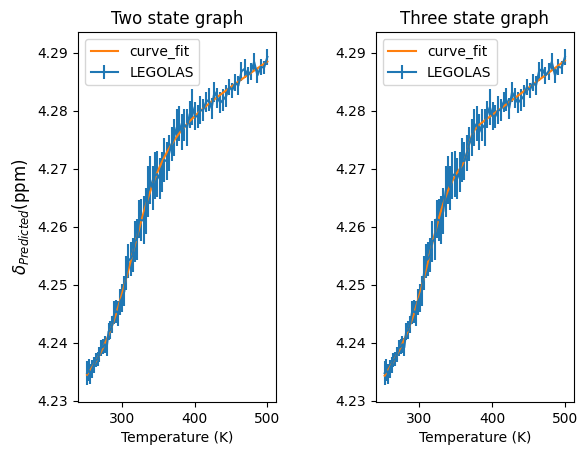

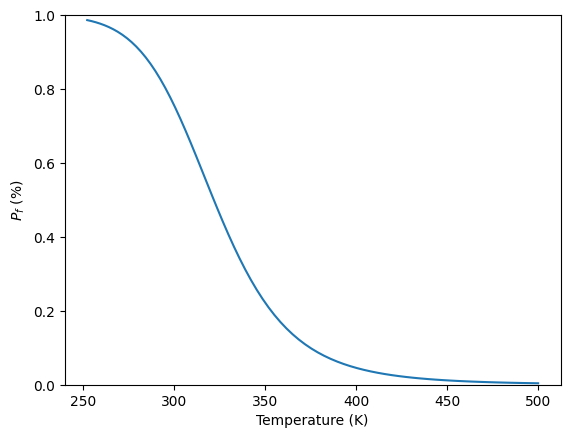

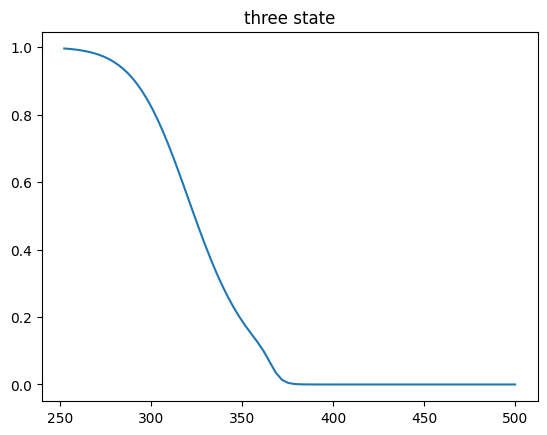

223 29
two state
Tm two state 357.95582555339547
dH two state 13.509284331480856
Tm three state 300.37003590140796 18.542938259053166
dH three state 10.000000000000002 276.1355944454181
29 amplitude too small
224 30
two state
Tm two state 326.27557418774035
dH two state 8.588698282865334
Tm three state 326.7627797827645 49.99088314675888
dH three state 10.30792574495253 20.100586572160193
0.0010202515879148067 0.0007446119425636984
cs_f 4.59909749883813


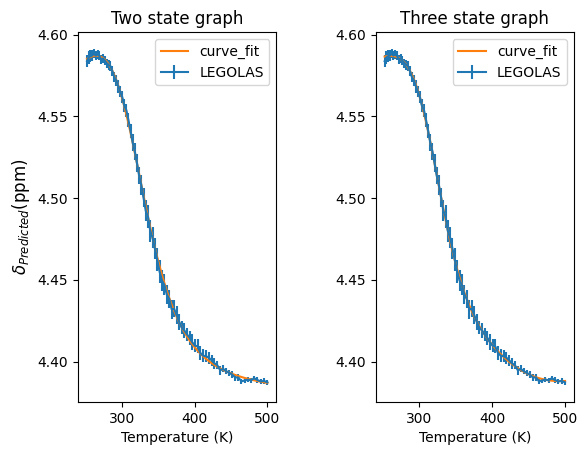

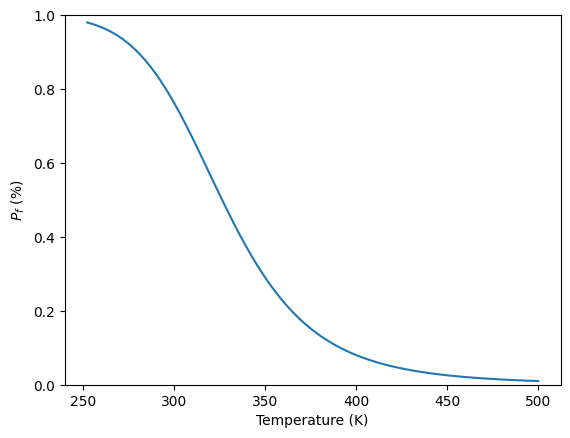

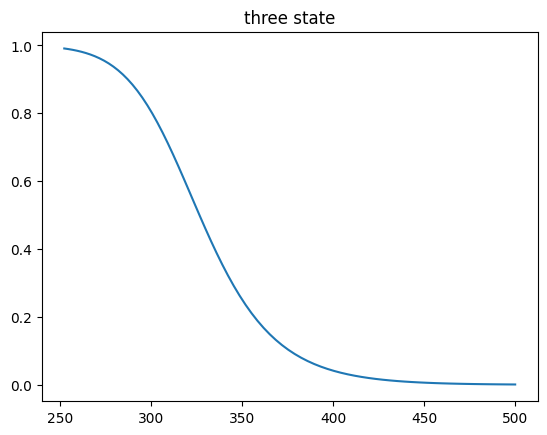

In [13]:
# selected predicted data fittings
import collections
import scipy
import scipy.optimize as optimize
import math
from sklearn.metrics import mean_absolute_error
import sympy
from scipy.optimize import differential_evolution

temp_exp_float=[]
melting_exp=[]
#def residuals_Mun(temp_exp_float,cs_f,cs_f_slope,cs_u,cs_u_slope,Tm,dH,shifts):
    #return shifts - two_state_func_Mun(temp_exp_float,cs_f,cs_f_slope,cs_u,cs_u_slope,Tm,dH)

#chemical_shifts = np.zeros(np.shape(shifts))
popt_store_predicted=collections.defaultdict(dict)
data={}   
Tm_195_234 = []
dH_195_234 = []
l = 0
resid=[5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,22,23,24,24,25,26,26,27,27,28,29,30,31,32,33,34,35,36,37,38]

for r in range(195,225):
    print(r,resid[l])

    x,y = zip(*(shifts_hip.get(str(r))).items())
    #x2,y2 = zip(*(shifts_hip_40.get(str(r))).items())
    #y2 = np.array(y2)
    x = np.array(x)
    #print(x,y)
    y = np.array(y)
    shifts = []
    temp = []
    for i in y:
        shifts.append(i)
    for i in x:
        temp.append(float(i))
    x,y = zip(*(stdv_hip.get(str(r))).items())
    x = np.array(x)
    #print(x,y)
    sigma = np.array(y[25:])
    
    shifts = np.array(shifts[25:])
    #print(shifts)

    temp = np.array(temp[25:])
    min_cs = (np.mean(shifts[:4]))
    max_cs = np.mean(shifts[-4:])
   

    lower_bounds_2 = [
        min_cs - 0.40,   # cs_f
        -0.0015,          # cs_f_slope
        max_cs - 0.4,   # cs_u
        -0.0015,           # cs_u_slope
        200,          # Tm
        0            # dH (kcal/mol)
    ]

    upper_bounds_2 = [
        min_cs + 0.40,   # cs_f
        +0.0015,           # cs_f_slope
        max_cs + 0.40,   # cs_u
        +0.0015,           # cs_u_slope
        500,          # Tm
        200           # dH
    ]


    lower_bounds = [
        min_cs - 0.2,  # cs_f
        -0.015,          # cs_f_slope
        max_cs - 0.2,  # cs_u
        -0.015,          # cs_u_slope
        280,         # Tm1 (K)
        5,         # Tm2 (K)
        10,          # dH1 (kcal/mol)
        10,          # dH2 (kcal/mol)
        np.mean(shifts)-0.15    # cs_i
    ]

    upper_bounds = [
        min_cs + 0.2,  # cs_f
        +0.015,          # cs_f_slope
        max_cs + 0.2,  # cs_u
        +0.015,          # cs_u_slope
        350,         # Tm1
        50,         # Tm2
        300,         # dH1
        300,         # dH2
        np.mean(shifts)+0.15    # cs_i
    ]
    p0_2 = [
    (np.mean(shifts[:4])),        # cs_f
    0.0,              # slope folded
    (np.mean(shifts[-4:])),       # cs_u
    0.0,              # slope unfolded
    330.0,            # Tm
    20.0             # dH in kcal/mol
    ]


    p0_3 = [
    shifts[0],        # cs_f
    0,                # cs_f_slope
    shifts[-1],       # cs_u
    0,                # cs_u_slope
    300,              # Tm1 (K)
    20,              # Tm2 (K)
    20,               # dH1 (kcal/mol)
    60,              # dH2 (kcal/mol)
    np.mean(shifts)   # cs_i 
    ]
    #p0=np.array([shifts[0],1e-6,shifts[39],1e-6,290.0,370.0,10,80,4],dtype=np.float128)
    
    shifts = shifts.astype(dtype=np.float64)
    temp = temp.astype(dtype=np.float64)
    def sumOfSquaredError_two(parameterTuple):
        val = two_state_func_Mun(temp, *parameterTuple)
        #print(val)
        return(np.sum((shifts-val)**2))
    def sumOfSquaredError_three(parameterTuple):
        val = three_state_func_Mun(temp, *parameterTuple)
        #print(val)
        return(np.sum((shifts-val)**2))
    
    def generate_Initial_Parameters_two():

        parameterBounds = []
        parameterBounds.append([(shifts[0])-0.03,(shifts[0])+0.03]) # search bounds for a
        parameterBounds.append([-0.1, +0.1]) # search bounds for b
        parameterBounds.append([(shifts[len(shifts)-1])-0.03, (shifts[len(shifts)-1])+0.03]) # search bounds for offset
        parameterBounds.append([-0.1, +0.1])
        parameterBounds.append([270, 400])
        parameterBounds.append([0, 100])

        #parameterBounds = np.array(parameterBounds)
        # "seed" the numpy random number generator for repeatable results
        result = differential_evolution(sumOfSquaredError_two, parameterBounds, tol=0.0000001)
        return result.x
    def generate_Initial_Parameters_three():
        parameterBounds = []
        parameterBounds.append([min(shifts)-0.05, min(shifts)+0.05]) # search bounds for a
        parameterBounds.append([-0.1, +0.1]) # search bounds for b
        parameterBounds.append([max(shifts)-0.05, max(shifts)+0.05]) # search bounds for offset
        parameterBounds.append([-0.1, +0.1])
        parameterBounds.append([290, 320])
        parameterBounds.append([320, 380])
        parameterBounds.append([5, 100])
        parameterBounds.append([5, 100])
        parameterBounds.append([min(shifts), max(shifts)])

        #parameterBounds = np.array(parameterBounds)
        # "seed" the numpy random number generator for repeatable results
        result = differential_evolution(sumOfSquaredError_three, parameterBounds,  tol=0.000001)
        return result.x
    geneticParameters_two = generate_Initial_Parameters_two()
    geneticParameters_three = generate_Initial_Parameters_three()
    

    popt_two_predicted, pcov_two_predicted=  optimize.curve_fit(two_state_func_Mun,xdata=temp,ydata = shifts,p0=p0_2,bounds=(lower_bounds_2,upper_bounds_2),sigma=sigma,absolute_sigma=True,maxfev=100000000)
    #popt_two_predicted, pcov_two_predicted=  optimize.curve_fit(two_state_func_Mun,xdata=temp,ydata = shifts,p0=[4.12,0.,4.17,0,330.0,20],maxfev=100000000,bounds=((3,-0.01,3,-0.01,280,0),(6,+0.01,6,+0.01,370,np.inf)))

    #popt_two_predicted, pcov_two_predicted=  optimize.curve_fit(two_state_func_Mun,xdata=temp,ydata = shifts,p0=[shifts[0],0.,shifts[38],0,310.0,20],maxfev=100000000,bounds=((3,-0.01,3,-0.01,300,0),(5,+0.01,5,+0.01,360,np.inf)))

    #popt_two_predicted, pcov_two_predicted=  optimize.curve_fit(two_state_func_Mun,xdata=temp,ydata = shifts,p0=geneticParameters_two,maxfev=100000000,bounds=(((shifts[0])-0.03,-0.1,(shifts[(len(shifts)-1)])-0.03,-0.1,270,0),((shifts[0])+0.03,+0.1,(shifts[(len(shifts)-1)])+0.03,+0.1,400,100)),sigma=sigma,absolute_sigma=True,jac=two_state_jacobian)

    popt_three_predicted, pcov_three_predicted=  optimize.curve_fit(three_state_func_Mun,xdata=temp,ydata = shifts,p0=p0_3,maxfev=10000000000,bounds=(lower_bounds,upper_bounds),sigma=sigma,absolute_sigma=True)
    #popt_two_predicted, pcov_two_predicted =  optimize.curve_fit(two_state_func_Mun,xdata=temp,ydata = shifts,p0=[3.96,1e-6,4.19,1e-6,303.0,20],maxfev=1000000,bounds=((3,-1,3,-1,300,19),(5,+1,5,+1,305,25)),absolute_sigma=True,sigma=sigma)
    #popt_hamborg_predicted, pcov_hamborg_predicted =  optimize.curve_fit(Hamborg,xdata=temp,ydata = shifts,p0=[3.96,4.19,0,0,0,20,2,304],maxfev=100000000,bounds=((3,3,-np.inf,-np.inf,-np.inf,-np.inf,-np.inf,300),(5,5,np.inf,np.inf,np.inf,np.inf,np.inf,305)))

    perr_two_predicted = np.sqrt(np.diag(pcov_two_predicted))
    perr_three_predicted = np.sqrt(np.diag(pcov_three_predicted))
    #perr_hamborg_predicted = np.sqrt(np.diag(pcov_hamborg_predicted))

    #3print('three error',perr_three_predicted)
    #print('three error',*perr_three_predicted)
    #print('three ',*popt_three_predicted)


    #print('three pcov',pcov_three_predicted)
    #print('two error',perr_two_predicted)
    #print('two',*popt_two_predicted)
    #print('two pcov',pcov_two_predicted)


    
    #print(*popt)
    #print(pcov)
    #perr = np.sqrt(np.diag(pcov))
    #print('perr', perr)
    #fig, ax = plt.subplots()
    fit_three_predicted = three_state_func_Mun(temp,*popt_three_predicted)
    fit_two_predicted = two_state_func_Mun(temp,*popt_two_predicted)
    ss1 = np.sum((shifts-fit_two_predicted)**2)
    ss2 = np.sum((shifts-fit_three_predicted)**2)
    df1=len(temp)-6
    df2=len(temp)-8
    F = ((ss1-ss2)/(df1-df2))/(ss2/df2)
    #print('F',F)
    #HA_id=[212,213,215,216,218,219,220,221]
    #resid=[22,22,24,24,26,26,27,27]

    if (F< 300):
        
        print('two state')
        
        #popt_store=collections.defaultdict(dict)
        popt_store_predicted[str(r)]=popt_two_predicted
        #print('resid', resid[l],data[f'Tm1_{resid[l]}'])
        if (l==0):
            data[f'dH1_{resid[l]}']=popt_two_predicted[5]
            data[f'dH1_err{resid[l]}']=perr_two_predicted[5]
            data[f'Tm1_{resid[l]}']=popt_two_predicted[4]
            data[f'Tm1_err{resid[l]}']=perr_two_predicted[4]
            
        
        elif (l>0) and (resid[l-1]==resid[l]):
            data[f'dHA2_1_{resid[l]}']=popt_two_predicted[5]
            data[f'TmA2_1_{resid[l]}']=popt_two_predicted[4]
            data[f'TmA2_1_err{resid[l]}']=popt_two_predicted[4]
            data[f'dHA2_1_err{resid[l]}']=perr_two_predicted[4]
        else:

            data[f'dH1_{resid[l]}']=popt_two_predicted[5]
            data[f'dH1_err{resid[l]}']=perr_two_predicted[5]
            data[f'Tm1_{resid[l]}']=popt_two_predicted[4]
            data[f'Tm1_err{resid[l]}']=perr_two_predicted[4]



    else:
        print('three state')

        popt_store_predicted[str(r)]=popt_three_predicted

        if (l>0) and (resid[l-1]==resid[l]):
            data[f'TmA2_1_{resid[l]}']=popt_two_predicted[4]
            data[f'TmA2_2_{resid[l]}']=popt_two_predicted[5]
            data[f'dHA2_2_{resid[l]}']=popt_two_predicted[6]
            data[f'dHA2_2_{resid[l]}']=popt_two_predicted[7]
        else:

            data[f"dH1_{resid[l]}"]=popt_three_predicted[6]
            data[f'dH2_{resid[l]}']=popt_three_predicted[7]

            data[f'Tm1_{resid[l]}']=popt_three_predicted[4]
            data[f'Tm2_{resid[l]}']=popt_three_predicted[5]

    #print('parameters two state',*popt_two_predicted)
    #print('parameters three state',*popt_three_predicted)
    print('Tm two state', popt_two_predicted[4])
    print('dH two state', popt_two_predicted[5])
    print('Tm three state', popt_three_predicted[4],popt_three_predicted[5])
    print('dH three state', popt_three_predicted[6],popt_three_predicted[7])
    #print('pcov two',pcov_two_predicted)
    #fit_hamborg_predicted = Hamborg(temp,*popt_hamborg_predicted)

    #if chi_square(shifts,fit_two_predicted,perr_two_predicted) < chi_square(shifts,fit_hamborg_predicted,perr_hamborg_predicted):
    #    print('Two state')
    #    print(popt_two_predicted)
    #else:
    #    print('Three state')

    #print(chi_square(shifts,fit_two_predicted,perr_two_predicted),chi_square(shifts,fit_three_predicted,perr_three_predicted),chi_square(shifts,fit_hamborg_predicted,perr_hamborg_predicted))
    #residue_exp[str(i)] = (params_exp)
    #melting_exp.append(popt[4])
    #chemical_shifts=np.vstack([chemical_shifts,shifts])
    l = l+1
    if max(shifts)-min(shifts)>=0.05:
        fig,(ax1,ax2) = plt.subplots(1,2)
        ax1.errorbar(x=temp,y=shifts,yerr=sigma,label='LEGOLAS')
        #ax1.plot(temp_40,y2,label='270-400',color='red')

        ax2.errorbar(x=temp,y=shifts,yerr=sigma,label='LEGOLAS')
        #ax3.errorbar(x=temp,y=shifts,yerr=sigma)
        ax1.plot(temp,fit_two_predicted,label='curve_fit')
        ax1.set_title('Two state graph')
        ax2.set_title('Three state graph')
        error_two = mean_absolute_error(shifts,fit_two_predicted)
        error_three = mean_absolute_error(shifts,fit_three_predicted)
        print(error_two,error_three)
        print('cs_f',popt_two_predicted[0])

        ax2.plot(temp,fit_three_predicted,label='curve_fit')
        #ax3.plot(temp,fit_hamborg_predicted)

        ticks=[]
        #ax.set_xticks(range(len(temp)))
        #ax.set_xlabel(['268.38',' ','277.64',' ','288.18','','298.34','','308.6','','317.54','','329','','338.664'])
        #ax.set_xticklabels(['268.38',' ','277.64',' ','288.18','','298.34','','308.6','','317.54','','329','','338.664'])
        ax1.set_xlabel('Temperature (K)')
        ax2.set_xlabel('Temperature (K)')

        #ax1.set_ylabel('')
        ax1.set_ylabel(r'$δ_{Predicted}$(ppm)',fontsize=12)
        ax1.legend()
        ax2.legend()
        #plt.scatter(y2,temp_40,label='270-400')

        #ax1.savefig(f'/blue/colina/dkodituwakku/plots-twostate-three-state/state-{r}.jpg')
        plt.subplots_adjust(wspace = 0.5)
        extent = ax1.get_window_extent().transformed(fig.dpi_scale_trans.inverted())

        fig.savefig(f'/blue/roitberg/dkodituwakku/plots-thesis/plots-twostate-{r}.jpg', bbox_inches=extent.expanded(2.0, 1.5),dpi=300)


        plt.show()

        #plt.title('Two state')
        plt.plot(temp,plot_pf_two(temp,*popt_two_predicted))
        plt.ylabel('$P_f$ (%)')
        plt.xlabel('Temperature (K)')
        plt.ylim(0.0,1.0)
        plt.savefig(f'/blue/roitberg/dkodituwakku/plots-thesis/plots-twostatepf-{r}.jpg',dpi=300)
        plt.show()
        plt.title('three state')
        plt.plot(temp,plot_pf_three(temp,*popt_three_predicted))

        plt.show()
        
    else:
        print(f'{l} amplitude too small')



In [35]:
print ("{:<8} {:<15}".format('Residue','Predicted Melting temperature'))
for l in range(5,10):
#for k, v in data.items():
    print("{:<8} {:<15}".format(l,data[f'Tm1_{l}']))


Residue  Melting temperature
5        353.3471589513269
6        499.9999999999089
7        394.2523979648036
8        363.76406776835904
9        367.3512845369216


In [62]:
import csv
    
def do_block_averaging(corr):
                    sems = list()
                    x=np.arange(len(corr))
                    #for blocksize in range(1, int(len(corr)//25)+1):
                    for blocksize in range(1, int(len(corr)**(2/3))+1):
                        #this is the blocking bit:
                        x_ = x[:len(x)-(len(x)%blocksize)].reshape(-1,blocksize).mean(1)
                        y_ = corr[:len(x)-(len(x)%blocksize)].reshape(-1,blocksize).mean(1)
                        sems.append(sem(y_))
                    return sems
class shift_reader:
    def __init__(self,filename,id1,id2):
        self.filename=filename
        self.id1=id1
        self.id2=id2
    def stdev_plot(self):
        
            
            df = pd.read_csv(self.filename,header=None,names = ['column_a', 'column_b', 'column_c','column_d','column_e','column_f'])
            #print(df["CHEMICAL_SHIFT"][195])
            #shift = df["CHEMICAL_SHIFT"]
            #print(df['column_d'])
            shift = df['column_d'].str.split(',')
            
            
                
                    
            for e in range(self.id1,self.id2):
                nums = []
                time= []
                p = shift[e]
                l = 0
                i = 0
                for h in p:

                    x  = re.split(r'\[|\]',h)


                    if (len(x)>1) and (i == 0):
                        
                        #print(temp,resid, x)
                        
                        nums.append(float(x[1]))
                        i = i+1
                        time.append(i*4e-15*7000*1e9)

                    else:
                        #print(x)
                        
                        nums.append(float(x[0]))
                        i = i+1
                        time.append(i*4e-15*7000*1e9)
                nums = np.array(nums)
                
                #plt.plot(time,nums)
                #plt.show()
                #print(nums)
                #auto = int(np.round(emcee.autocorr.integrated_time((nums-statistics.mean(nums))/statistics.stdev(nums)))[0])
                #print('auto',auto)
                mean_store = []
                block_size=[]
                no_blocks=[]
                block_size_no=[]
                sem=[]
                
                #return sems
                for n_blocks in range(200,10,-1):
                    #block_size.append(i)
                    #block_mean=[]
                    #no_blocks=0
                    #mean=0
                    #for l in range(0, len(nums),i):
                    #    print(l)
                    #    if len(nums[:l+i])==i:
                    #        block_mean.append(np.mean(nums[l:l+i]))
                 #           #mean=mean+(np.mean(nums[l:l+i])**2)
                    #        no_blocks=no_blocks+1
                    #sem.append(np.std(block_mean)/np.sqrt(no_blocks))
                    block_size=len(nums)//n_blocks
                    #print(n_blocks,block_size)
                    lim=(int(n_blocks*block_size))
                    blocks=nums[:lim].reshape(n_blocks,block_size)
                    #print(blocks)
                    block_mean=blocks.mean(axis=1)
                    #print(block_mean)
                    no_blocks.append(n_blocks)
                    block_size_no.append(block_size)
                    sem.append(np.std(block_mean)/np.sqrt(n_blocks))
                #plt.plot(block_size_no,sem)
                    #print(sem)
                    
                    
                    
                #sem = do_block_averaging(nums)
                #print(sem)
                sem=np.array(sem)
                block_size_no=np.array(block_size_no)
                #popt,pcov=optimize.curve_fit(f,xdata=block_size_no,ydata = sem,maxfev=1000000,p0=[0.001,0.001,(0.5*(np.max(block_size_no)+np.min(block_size_no))),(0.5*(np.max(sem)+np.min(sem)))],bounds=((0,0,0,0),(np.inf,np.inf,np.inf,np.inf)))
                popt2,pcov2=optimize.curve_fit(polynomial,xdata=block_size_no,ydata = sem,p0=[0.00,0.0002])
                #print(popt)
                #print(popt2)
                #plt.ylabel('SEM (ppm)')
                #plt.xlabel('block size')
                #plt.plot(block_size_no,f(block_size_no,*popt2))
                #print('f',f(block_size,*popt))
                #plt.plot(block_size_no,polynomial(block_size_no,*popt2))
                #plt.plot(block_size,f(block_size,*popt))
                #print(block_size_no)
                #plt.plot(block_size_no,sem)
                #plt.legend(['Quadratic-plateau','SEM'])
                #plt.savefig('/blue/colina/dkodituwakku/plots-thesis/sem_5HA.jpg',dpi=300)
                
                #plt.show()
                #plt.ylabel('SEM')
                #plt.xlabel('number of blocks')
                #plt.plot(block_size,f(block_size,*popt))
                
                #plt.plot(no_blocks,sem)
                
                #plt.show()
                #print(nums)
                #while last <= 20000:
                #for l in range(0,len(nums),auto):
                #    mean_store.append(np.mean(nums[l:l+auto]))
                #print(mean_store)
                #means1 = np.mean(nums)
                #tot = 0
                #for y in range(0,len(mean_store)):
                #    x=(mean_store[y]-means1)**2
                #    tot = x + tot
                #std =(tot/len(mean_store))
                #std = statistics.stdev(mean_store)
                #Neff = len(nums)/emcee.autocorr.integrated_time(nums)
                #error = (statistics.stdev(nums))/np.sqrt(Neff)
                #print('emcee error',error)
                #plt.plot([sem(block_reduce(nums, (i,), func=np.mean)) for i in range(1,500)], '-o')
                #plt.show()
                n = len(nums)
                #variance = nums.var()
                #numdiff = nums-nums.mean()
                #r = np.correlate(numdiff, numdiff, mode = 'full')[-n:]
                #assert np.allclose(r, np.array([(x[:n-k]*x[-(n-k):]).sum() for k in range(n)]))
                #result = r/(variance*(np.arange(n, 0, -1)))
                #plt.plot(time[0:10],result[0:10])
                
                #plt.show()
                #acf_out=acf(nums)
                #acf_out=np.array(acf_out)
                #print(acf_out)
                #print(len(positive_acf))
                
                #print('positive',result)
                #print(cutoff)


                #delta_plus=0+(1.96/np.sqrt(len(nums[100:])))
                #delta_negative=0-(1.96/np.sqrt(len(nums[100:])))
                #plt.axhline(delta_plus,color='r', linestyle='-')
                #plt.axhline(delta_negative,color='r', linestyle='-')
                #time = sm.tsa.stattools.acf(nums)
                
                #num=pd.Series(nums)
                #auto = [num.autocorr(lag=i) for i in range(10000)]
                #auto=np.array(auto)
                #timex=[]
                #for i in range(10000):
                 #   timex.append(i)
                    
                #print('tau1',tau_cal(acf_out,nums))

                #print('tau',tau_cal(auto,nums))
                #print('statsmodels',tau_cal(time,nums))
                #plt.plot(timex,auto)
                #plt.show()

                #plt.plot(acf_out[0:5000])
                #plt.show()
                #plt.show()
                #print(nums)
                #print(e)
                yield (statistics.mean(nums[50000:]),popt2[1],e)
                #yield (nums[0],nums[-1],popt2[1],e)
def shifts_mean(temp,id1,id2):
    

    shifts={}
#    files = f'/orange/colina/dkodituwakku/remd/remd-explicit/md/closest180-270.0-2_cs.csv'
    
    
        #for g in range(4,11):
    
    for g in range(id1,id2):
    #HA 28-38 - 222,233
    #HA 12-27 - 202,222
    #HA 5-11 - 195,202
    
        p,stdv,i = stdev_plot(files,g)
        print(g)
        return g,p, stdv
               
import collections
shifts_hip_test=[]

#shifts = defaultdict(dict)
#shifts={}
resids=[]
for i in range(195,234):
    resids.append(i)
#resids=[217]
temp=[]
with open ("/orange/roitberg/dkodituwakku/bbl-opc3/remd-200-500/md2/temperatures.dat") as obj:
                
#with open ("/orange/colina/dkodituwakku/remd/remd-explicit/temperatures.dat") as obj:
#with open ("/orange/roitberg/dkodituwakku/bbl-opc3/remd-350-500/md/temp_extracts/temp_analysis.dat") as obj:

    for line in obj:
        cols= line.split()
        temperatures = float(cols[0])
        #print(temperatures)
        temp.append(temperatures)
        
 #   print('i',i)
#print(shifts_hip)
for l in temp:
        print(l)
        files = f'/blue/roitberg/dkodituwakku/bbl-opc3/remd-200-500/md2/temp_extracts/line210-{l}.csv'
        #if 199.0 < l <= 350.00:
        #     l = '{:.2f}'.format(round(l, 2))
        #     files = f'/orange/roitberg/dkodituwakku/bbl-opc3/remd-200-350-trial3/md2/temp_extracts/closest180-{l}_cs.csv'
        #elif 400.0 < l < 502.0:
        #    files = f'/orange/roitberg/dkodituwakku/bbl-opc3/remd-350-500/md/temp_extracts/closest180-{l}_cs.csv'
        #else:

        #    files = f'/blue/colina/dkodituwakku/remd-explicit/closest180-{l}-test_cs.csv'
        reader=shift_reader(files,0,1)
        for shift in reader.stdev_plot():
        
        #shift,stdv,idx = stdev_plot(files,195,234)
        #print(idx,'shift',shift,stdv)
            #print(shift[2],l)
            shifts_hip_test.append(shift)

200.0
201.9
203.7
205.6
207.5
209.5
211.4
213.4
215.4
217.4
219.4
221.4
223.5
225.6
227.7
229.8
231.9
234.1
236.3
238.5
240.7
242.9
245.2
247.4
249.7
252.1
254.4
256.8
259.2
261.6
264.0
266.5
268.9
271.4
274.0
276.5
279.1
281.7
284.3
286.9
289.6
292.3
295.0
297.8
300.5
303.3
306.2
309.0
311.9
314.8
317.7
320.7
323.6
326.6
329.7
332.8
335.8
339.0
342.1
345.3
348.5
351.8
355.0
358.3
361.7
365.0
368.4
371.8
375.3
378.8
382.3
385.9
389.5
393.1
396.7
400.4
404.1
407.9
411.7
415.5
419.4
423.3
427.2
431.2
435.2
439.3
443.3
447.5
451.6
455.8
460.1
464.3
468.7
473.0
477.4
481.8
486.3
490.9
495.4
500.0


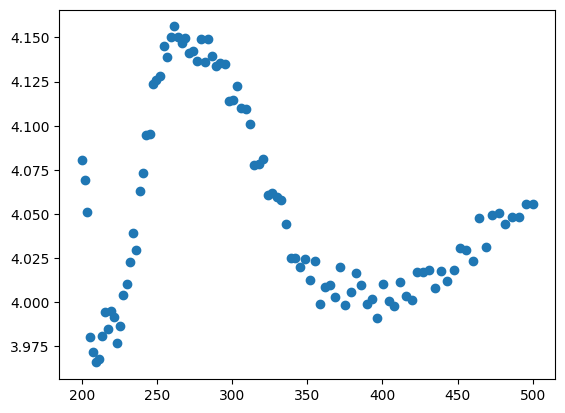

In [63]:

shift=[]
for i in range(0,len(shifts_hip_test)):
    
    shift.append( shifts_hip_test[i][0])
    
plt.scatter(temp,shift)